# ▶️ Initialisation
⚠️ Require Pubchem API, therefore, internet 🌐

Note:
Updated xm values for metals (consistent with ore grade decline).
**How CFs are applied to natural resources (EF content? ☑️) or to EF pure?**

Restorative, how to Apply ERC CF to Elementary flows?

 ## 📖 libraries

In [361]:
# =============================================
# Data Processing and Numerical Libraries
# Used for data manipulation, math, and array operations
# =============================================
import numpy as np  # Numerical computing (arrays, math operations), only version for np.nan # numpy==1.26.4
import pandas as pd # Data manipulation and analysis (DataFrames)
import math         # Basic math functions
import csv          # CSV file reading/writing
import re           # Regular expressions (text pattern matching)
import json
import hashlib
import shutil       # Delete cache folder when needed

# =============================================
# File System and Path Handling
# Used for file and directory operations
# =============================================
import os           # Operating system interfaces (file paths, environment variables)
from pathlib import Path  # Object-oriented filesystem paths
from typing import Dict, List, Tuple, Optional, Any
from datetime import datetime


# =============================================
# Time and Delay Utilities
# Used for introducing delays or measuring time
# =============================================
from time import sleep  # Introduce delays (e.g., for web scraping)
import time             # Time-related functions (e.g., `time.time()`)

# =============================================
# Core Scientific/LCA (Life Cycle Assessment) Libraries
# Required for Brightway2.5 (LCA framework)
# Always place these at the top, as they are the main dependencies for your project
# =============================================
import bw2io as bi # Brightway library for data import/export
import bw2data as bd # Core Brightway library for LCA database management
import bw2calc as bc

# =============================================
# Chemistry and Data Retrieval
# Used for chemical data and external API access
# =============================================
import pubchempy as pcp                 # Interface to PubChem (chemical data)
from pubchempy import PubChemHTTPError, get_compounds  # Unique CF assignment for each flow that contains copper
import requests                         # HTTP requests (e.g., API calls)
from mendeleev import element           # Periodic table data (element properties)

## brightway

In [362]:
# Set up the project and database
project_name = "CERC" # Name of the project, choose wisely according to list(bd.projects)
bd.projects.set_current(project_name)

# Retrieves credentials that are stored in the os.
username = os.getenv("EI_USERNAME")
password = os.getenv("EI_PASSWORD")

# Use this code if the project is not imported yet
# bi.import_ecoinvent_release("3.4", "cutoff", username, password)

# 1. Initialize the database object
biosphere_db = bd.Database('ecoinvent-3.4-biosphere')

bd.databases

Databases dictionary with 2 object(s):
	ecoinvent-3.4-biosphere
	ecoinvent-3.4-cutoff

In [363]:
bd.projects.set_current("CERC")

### bw project managment

In [364]:
# backup_dir = r"C:\Users\louis\.github\Exergy-Ore-Grade-Decrease-Model\bw_backups"
# bi.backup.backup_project_directory(
#     project=bd.projects.current,
#     dir_backup=backup_dir 
# )

# # Path to your backup file
# backup_path = Path(r"C:\Users\louis\.github\Exergy-Ore-Grade-Decrease-Model\bw_backups\brightway2-project-CERC-backup31-July-2026-01-18AM.tar.gz")

# # Create a new project name (clean, uncorrupted)
# new_project_name = "CERC_workflow"

# print(f"Restoring backup to new project: {new_project_name}")
# print(f"Backup file: {backup_path}")
# print(f"Backup exists: {backup_path.exists()}")

# # Restore the backup as a new project
# try:
#     restored_name = bi.backup.restore_project_directory(
#         fp=str(backup_path),
#         project_name=new_project_name,
#         overwrite_existing=False,  # Don't overwrite if exists
#         switch=True  # Switch to this project after restore
#     )
#     print(f"\n✓ Project successfully restored as: {restored_name}")
#     print(f"Current project: {bd.projects.current}")
    
# except Exception as e:
#     print(f"Error during restore: {e}")
#     print("\nTrying alternative method...")

## Input data

### helper dict

In [365]:
symbol_map = {
    'Al': 'Aluminium',
    'Sb': 'Antimony',
    'As': 'Arsenic',
    'Ba': 'Barium',
    'Be': 'Beryllium',
    'Bi': 'Bismuth',
    'Cd': 'Cadmium',
    'Ce': 'Cerium',
    'Cr': 'Chromium',
    'Co': 'Cobalt',
    'Cu': 'Copper',
    'F': 'Fluor',
    'Gd': 'Gadolinium',
    'Ga': 'Gallium',
    'Ge': 'Germanium',
    'Au': 'Gold',
    'Ca': 'Calcium',
    'Hf': 'Hafnium',
    'In': 'Indium',
    'Fe': 'Iron',
    'La': 'Lanthanum',
    'Pb': 'Lead',
    'Li': 'Lithium',
    'Mg': 'Magnesium',
    'Mn': 'Manganese',
    'Hg': 'Mercury',
    'Mo': 'Molybdenum',
    'Nd': 'Neodymium',
    'Ni': 'Nickel',  # Will match both "Nickel (sulphides)" and "Nickel (laterites)"
    'Nb': 'Niobium',
    'Pd': 'Palladium',
    'P': 'Phosphorus',
    'Pt': 'Platinum',
    'K': 'Potassium',
    'Pr': 'Praseodymium',
    'Re': 'Rhenium',
    'Si': 'Silicon',
    'Ag': 'Silver',
    'Na': 'Sodium',
    'Sr': 'Strontium',
    'Ta': 'Tantalum',
    'Te': 'Tellurium',
    'Tl': 'Thallium',
    'Sn': 'Tin',
    'Ti': 'Titanium',
    'U': 'Uranium',
    'V': 'Vanadium',
    'W': 'Tungsten',
    'Y': 'Yttrium',
    'Zn': 'Zinc',
    'Zr': 'Zirconium'
}

### Literature

* In depht method ➡️ Vieira et al. (2012) 🪢 https://repository.ubn.ru.nl/handle/2066/103594
* In depht data ➡️ Vieira et al. (2016) 
    supporting information 🪢 https://onlinelibrary.wiley.com/action/downloadSupplement?doi=10.1111%2Fjiec.12444&file=jiec12444-sup-0001-SuppMat.pdf
    article for URR, A, and CME 🪢 https://doi.org/10.1111/jiec.12444
* In 'sop-vieira-constants_new.csv', the $URR$ values are updated for Iron (Fe), in order to yield a *correct* value for the initial mass fraction of Fe in ore (i.e., $0>x_{i, Me}>=1$):  
  $x_{i, Me}=e^{\alpha}(\frac{URR}{CME}-1)^{\beta}$. The new URR value are taken from 🪢https://doi.org/10.1007/s13563-023-00368-0 also in Scihub 🪢 https://sci-hub.fr/10.1007/s13563-021-00283-2. The grade of Iron ore is reported to be between 0.4 and 0.59, for an $URR$ estimation of 1.07E+14 kg (107,147 million of tons), i.e., $URR$ between 4.28E+13 and 6.31E+13 kg, which yield an $x_{i, Fe}$ between 0.47 and 0.55. We therefore select $URR$ = 4.28E+13 kg.
  


## parameter cells

In [366]:
# PARAMETERS (inject these)
# 🎯
viera_data = "new" # can be (a) "old" or (b) "new"

if viera_data == "old":
    pc1 = "a"
elif viera_data == "new":
    pc1 = "b"

viera_csv_input_data = f"inputs/sop-vieira-constants_{viera_data}.csv" 
valero_csv_input_data = "inputs/valero-constants.csv"

# 🎯
focus = "dissipation"  # (i)"natural_resources" or (ii) "dissipation"

if focus == "natural_resources":
    pc3 = "i"
    lci_accounting_approach = "Input-based"
elif focus == "dissipation":
    pc3 = "ii"
    lci_accounting_approach = "Dissipation-based"

# 🎯
input_for_xi = viera_csv_input_data # (1) valero_csv_input_data or (2) viera_csv_input_data (3) "elementary_flow"

# Option 3 ("elementary_flow") only makes sense for input-based accounting (natural resources),
# since dissipated flows carry no ore-grade-decline signal.
if focus == "dissipation" and input_for_xi == "elementary_flow":
    raise ValueError("input_for_xi='elementary_flow' is incompatible with focus='dissipation' "
                     "(dissipation-based accounting). Use 'valero_csv_input_data' or 'viera_csv_input_data'.")

if input_for_xi == viera_csv_input_data:
    viera_df = pd.read_csv(viera_csv_input_data)
    # Calculate xi for each metal using the Viera formula
    viera_df['xi'] = np.exp(viera_df['alpha']) * ((viera_df['URR'] / viera_df['CME']) - 1) ** viera_df['beta']
    # Save or use directly
    viera_df.to_csv(f'inputs/viera_with_xi_{viera_data}.csv', index=False)
    viera_csv_input_data = f"inputs/viera_with_xi_{viera_data}.csv"
    input_for_xi = viera_csv_input_data
    pc2 = "1"
elif input_for_xi == valero_csv_input_data:
    pc2 = "2"
elif input_for_xi == "elementary_flow":
    pc2 = "3"

# 🎯
apply_ogd = "n"  # (y) yes - compute OGD CFs and apply ore-grade-decline grading, or (n) no - skip OGD CF generation

if apply_ogd == "y":
    pc4 = "y"
elif apply_ogd == "n":
    pc4 = "n"
else:
    raise ValueError("apply_ogd must be 'y' or 'n'.")

parameter_code = f"{pc1}{pc2}{pc3}{pc4}"  # (a) "b1iiy" or (b) "b1iin" or (c) "b2iiy" or (d) "b2iin", ...
print(f"Parameter code: {parameter_code}")

def log_parameter_test(parameter_code, focus, input_for_xi, viera_data, log_file="parameter_tests_log.txt"):
    """
    Append a line to the log file each time a parameter_code is tested.
    """
    # Create log entry
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    log_entry = (
        f"{timestamp} | "
        f"code: {parameter_code} | "
        f"viera: {viera_data} | "
        f"focus: {focus} | "
        f"xi_source: {input_for_xi} | "
        f"ogd: {apply_ogd}\n"
    )
    
    # Append to file
    with open(log_file, "a") as f:
        f.write(log_entry)
    
    print(f"✅ Logged parameter test: {parameter_code}")

# ============================================================================
# USAGE
# ============================================================================

# After generating parameter_code, call the function
log_parameter_test(parameter_code, focus, input_for_xi, viera_data)

# Example output in log file:
# 2026-08-14 15:30:45 | code: b1iiy | viera: new | focus: dissipation | xi_source: valero_csv_input_data
# 2026-08-14 15:31:20 | code: b1iin | viera: new | focus: dissipation | xi_source: viera_csv_input_data
# 2026-08-14 15:32:10 | code: b2iiy | viera: old | focus: natural_resources | xi_source: valero_csv_input_data

Parameter code: b1iin
✅ Logged parameter test: b1iin


# ⏳ Marginalist Perspective (similar to Hierarchist cultural perspective)

## Step 1: Calcul the CF1

### Functions

#### Inputs data validity

In [367]:
def check_resource_limits(csv_file):
    """
    Check the physical and mathematical consistency of Vieira et al. constants.
    """

    df = pd.read_csv(csv_file)

    print("=" * 70)
    print("Checking resource constraints")
    print("=" * 70)

    # ---------------------------------------------------------
    # Positivity checks
    # ---------------------------------------------------------
    for col in ["URR", "A", "Rr", "CME"]:
        failed = df[df[col] <= 0]

        if failed.empty:
            print(f"✓ All {col} values are positive.")
        else:
            print(f"\n✗ Non-positive {col} values:")
            for _, row in failed.iterrows():
                print(f"  {row['Metal']}: {col} = {row[col]:.3e}")

    # ---------------------------------------------------------
    # CME should not exceed available resources
    # ---------------------------------------------------------
    checks = {
        "URR": "Ultimate Recoverable Resources",
        "Rr": "Reserves",
        "A": "A parameter (Vieira)"
    }

    for col, description in checks.items():

        failed = df[df["CME"] > df[col]]

        if failed.empty:
            print(f"✓ All metals satisfy CME <= {col} ({description}).")
        else:
            print(f"\n✗ CME > {col} ({description}):")
            for _, row in failed.iterrows():
                print(
                    f"  {row['Metal']}: "
                    f"CME={row['CME']:.3e}, "
                    f"{col}={row[col]:.3e}"
                )

    # ---------------------------------------------------------
    # Expected hierarchy
    # ---------------------------------------------------------
    hierarchy = [
        ("Rr", "A"),
        ("A", "URR"),
        ("Rr", "URR"),
    ]

    for lower, upper in hierarchy:

        failed = df[df[lower] > df[upper]]

        if failed.empty:
            print(f"✓ {lower} <= {upper} for all metals.")
        else:
            print(f"\n⚠ {lower} > {upper}:")
            for _, row in failed.iterrows():
                print(
                    f"  {row['Metal']}: "
                    f"{lower}={row[lower]:.3e}, "
                    f"{upper}={row[upper]:.3e}"
                )

    # ---------------------------------------------------------
    # Mathematical validity of CF1
    # ---------------------------------------------------------
    failed = df[df["A"] <= df["CME"]]

    if failed.empty:
        print("✓ All metals satisfy A > CME (CF1 mathematically valid).")
    else:
        print("\n✗ CF1 undefined because A <= CME:")
        for _, row in failed.iterrows():
            print(
                f"  {row['Metal']}: "
                f"A={row['A']:.3e}, "
                f"CME={row['CME']:.3e}"
            )

    print("=" * 70)

#### OGD

In [368]:
def calculate_ogd_dict(
    csv_path=viera_csv_input_data,
    use_column="URR",
    debug=False,
):
    """
    Calculate the CF1 dictionary for the 17 elements of interest from Vieira et al. (2016).

    Parameters
    ----------
    csv_path : str
        Path to the CSV file.

    use_column : str
        Resource quantity to use ('URR', 'A', or 'Rr').

    debug : bool
        If True, print intermediate calculations and consistency checks.

    Returns
    -------
    dict
        Dictionary {element_symbol: CF1}.
    """

    # ------------------------------------------------------------------
    # Read data
    # ------------------------------------------------------------------
    OGD_df = pd.read_csv(csv_path)

    if use_column not in ["URR", "A", "Rr"]:
        raise ValueError("use_column must be one of 'URR', 'A', or 'Rr'.")

    if use_column not in OGD_df.columns:
        raise ValueError(
            f"Column '{use_column}' not found. "
            f"Available columns: {list(OGD_df.columns)}"
        )

    # ------------------------------------------------------------------
    # Force float64 (avoids integer overflow)
    # ------------------------------------------------------------------
    A = OGD_df[use_column].astype(np.float64)
    CMT = OGD_df["CME"].astype(np.float64)
    alpha = OGD_df["alpha"].astype(np.float64)
    beta = OGD_df["beta"].astype(np.float64)

    # ------------------------------------------------------------------
    # Compute intermediate terms
    # ------------------------------------------------------------------
    numerator = A * beta * np.exp(alpha)
    denominator = CMT * (A - CMT)
    ratio = A / CMT - 1
    ratio_term = ratio ** beta

    cf1 = (numerator / denominator) * ratio_term # * 0.01

    OGD_df["CF1"] = cf1

    # ------------------------------------------------------------------
    # DEBUG
    # ------------------------------------------------------------------
    if debug:

        debug_df = pd.DataFrame({
            "Metal": OGD_df["Metal"],
            "Symbol": OGD_df["Symbol"],
            "A": A,
            "CME": CMT,
            "alpha": alpha,
            "beta": beta,
            "A-CME": A - CMT,
            "ratio": ratio,
            "ratio_term": ratio_term,
            "numerator": numerator,
            "denominator": denominator,
            "CF1": cf1,
        })

        print("\n==================== DATA TYPES ====================")
        print(OGD_df.dtypes)

        print("\n==================== DEBUG TABLE ====================")
        with pd.option_context(
            "display.max_rows", None,
            "display.max_columns", None,
            "display.width", 200,
            "display.float_format", "{:.6e}".format,
        ):
            print(debug_df)

        print("\n==================== CONSISTENCY CHECKS ====================")

        checks = {
            "A <= 0": A <= 0,
            "CME <= 0": CMT <= 0,
            "A <= CME": A <= CMT,
            "Numerator < 0": numerator < 0,
            "Denominator < 0": denominator < 0,
            "Ratio <= 0": ratio <= 0,
            "ratio_term < 0": ratio_term < 0,
            "CF1 < 0": cf1 < 0,
            "CF1 is NaN": np.isnan(cf1),
            "CF1 is Inf": np.isinf(cf1),
        }

        for name, mask in checks.items():
            if mask.any():
                print(f"\n❌ {name}")
                print(debug_df.loc[mask, ["Metal", "Symbol", "A", "CME", "ratio", "ratio_term", "denominator", "CF1"]])
            else:
                print(f"✓ {name}")

        print("\n==================== SIGN SUMMARY ====================")
        print(f"Numerator positive   : {(numerator > 0).all()}")
        print(f"Denominator positive : {(denominator > 0).all()}")
        print(f"Ratio positive       : {(ratio > 0).all()}")
        print(f"Ratio term positive  : {(ratio_term > 0).all()}")
        print(f"CF1 positive         : {(cf1 > 0).all()}")

    # ------------------------------------------------------------------
    # Remove gold
    # ------------------------------------------------------------------
    OGD_df = OGD_df[OGD_df["Metal"] != "Gold"]

    return dict(zip(OGD_df["Symbol"], OGD_df["CF1"]))

#### CF1_EF

In [369]:
# ============================================================================
# IMPORTS
# ============================================================================

import re
import time
import json
import hashlib
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
import pubchempy as pcp
from pubchempy import PubChemHTTPError
import pandas as pd
import numpy as np


# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_atomic_weight_from_pubchem(element: str) -> float:
    """
    Get atomic weight for an element using PubChem API.
    Falls back to hardcoded values if API fails.
    """
    try:
        compound = pcp.get_compounds(element, 'name')
        if compound and len(compound) > 0: # type: ignore
            # Get the element's atomic weight from its molecular weight
            # For pure elements, molecular weight = atomic weight
            mw = compound[0].molecular_weight
            if mw is not None:
                return float(mw)
    except Exception:
        pass
    
    # Fallback to hardcoded atomic weights
    return get_atomic_weight_fallback(element)


# Simplified fallback (only for elements not in PubChem or API failures)
def get_atomic_weight_fallback(element: str) -> float:
    """Minimal fallback for elements not found in PubChem."""
    fallback = {
        'H': 1.008, 'He': 4.003, 'Li': 6.941, 'Be': 9.012, 'B': 10.81,
        'C': 12.011, 'N': 14.007, 'O': 15.999, 'F': 18.998, 'Ne': 20.180,
        'Na': 22.990, 'Mg': 24.305, 'Al': 26.982, 'Si': 28.086, 'P': 30.974,
        'S': 32.065, 'Cl': 35.453, 'Ar': 39.948, 'K': 39.098, 'Ca': 40.078,
        'Ti': 47.867, 'V': 50.942, 'Cr': 51.996, 'Mn': 54.938,
        'Fe': 55.845, 'Co': 58.933, 'Ni': 58.693, 'Cu': 63.546, 'Zn': 65.380,
        'Ga': 69.723, 'Ge': 72.630, 'As': 74.922, 'Se': 78.971, 'Br': 79.904,
        'Kr': 83.798, 'Rb': 85.468, 'Sr': 87.620, 'Y': 88.906, 'Zr': 91.224,
        'Nb': 92.906, 'Mo': 95.950, 'Ru': 101.070, 'Rh': 102.906,
        'Pd': 106.420, 'Ag': 107.868, 'Cd': 112.414, 'In': 114.818, 'Sn': 118.710,
        'Sb': 121.760, 'Te': 127.600, 'I': 126.904, 'Xe': 131.293, 'Cs': 132.905,
        'Ba': 137.327, 'La': 138.905, 'Ce': 140.116, 'Pr': 140.908, 'Nd': 144.243,
        'Sm': 150.362, 'Eu': 151.964, 'Gd': 157.250, 'Tb': 158.925,
        'Dy': 162.500, 'Ho': 164.930, 'Er': 167.259, 'Tm': 168.934, 'Yb': 173.045,
        'Lu': 174.967, 'Hf': 178.490, 'Ta': 180.948, 'W': 183.840, 'Re': 186.207,
        'Os': 190.230, 'Ir': 192.217, 'Pt': 195.084, 'Au': 196.967, 'Hg': 200.592,
        'Tl': 204.380, 'Pb': 207.200, 'Bi': 208.980, 'U': 238.029
    }
    return fallback.get(element, 0.0)


def clean_chemical_name(name: str) -> str:
    """
    Clean chemical names for PubChem API lookup.
    
    Priority:
    1. Take everything before the first comma
    2. Remove Roman numerals (e.g., Aluminium III → Aluminium)
    3. Remove 'ion' or 'ions' suffix (e.g., Copper ion → Copper)
    """
    # Take everything before the first comma
    if ',' in name:
        name = name.split(',')[0].strip()
    
    # Remove Roman numerals at the end
    name = re.sub(r"\s+[IVXLCDM]+$", "", name)
    
    # Remove 'ion' or 'ions' at the end
    name = re.sub(r"\s+ions?$", "", name, flags=re.IGNORECASE)
    
    return name.strip()


def chem_comp(mf: str) -> List[List]:
    """
    Parse molecular formula into element parts.
    
    Example: "FeS2" -> [['Fe', 1], ['S', 2]]
    """
    pattern = r"([A-Z][a-z]?)(\d*)"
    matches = re.findall(pattern, mf)
    parts = []
    for elem, count in matches:
        count = int(count) if count else 1
        parts.append([elem, count])
    return parts


def cf_calculator(dict: Dict, mw: float, parts: List[List]) -> float:
    """
    Calculate the CF for a compound using the weighted sum of its elements.
    
    Formula: CF = sum(count * (aw_i / mw) * CF1_i)
    """
    cf = 0
    for elem, count in parts:
        if elem in dict.keys():
            mass = get_atomic_weight_fallback(elem) # is faster than using PubChem API for each element
            if mass == 0:
                continue
            cf += count * (mass / mw) * dict[elem]
    return cf


def has_elem(parts: List[List], dict: Dict) -> bool:
    """Check if any element in parts is in the dictionary (scope)."""
    for elem, count in parts:
        if elem not in dict.keys():
            print(f"  {elem} is not included in the scope.")
            continue
        else:
            return True
    return None # type: ignore


def parse_multi_element_ore(name: str) -> List[Tuple[str, float]]:
    """
    Parse multi-element ore flows to extract elements and their mass fractions.
    
    Handles:
    - "Cu 0.76%" 
    - "Ni 0.76%" 
    - "Mo 8.2E-3%"
    """
    elements = []
    
    # Pattern: Element symbol followed by number with optional scientific notation and "%"
    pattern_pct = r'([A-Z][a-z]?)\s+([\d.]+(?:E[+-]?\d+)?)\s*%'
    matches_pct = re.findall(pattern_pct, name)

    # Pattern: Element symbol followed by number with "ppm" (1 ppm = 1e-6 kg/kg)
    pattern_ppm = r'([A-Z][a-z]?)\s+([\d.]+(?:E[+-]?\d+)?)\s*ppm'
    matches_ppm = re.findall(pattern_ppm, name)

    seen_elements = set()
    for elem, value in matches_pct:
        if elem not in seen_elements:
            try:
                fraction = float(value) / 100
                elements.append((elem, fraction))
                seen_elements.add(elem)
            except ValueError:
                continue
    for elem, value in matches_ppm:
        if elem not in seen_elements:
            try:
                fraction = float(value) * 1e-6   # ppm -> mass fraction
                elements.append((elem, fraction))
                seen_elements.add(elem)
            except ValueError:
                continue

    return elements


def calculate_compound_composition(parts: List[List], mw: float, fraction: float = 1.0) -> Dict[str, float]:
    """
    Calculate mass fractions for a compound.
    
    Parameters:
    -----------
    parts : List[List]
        List of [element, count] pairs from chem_comp
    mw : float
        Molecular weight
    fraction : float
        Ore grade fraction (default 1.0)
    
    Returns:
    --------
    Dict[str, float]
        Dictionary mapping element symbol to mass fraction
    """
    composition = {}
    for elem, count in parts:
        aw = get_atomic_weight_fallback(elem) # is faster than using PubChem API for each element
        if aw > 0:
            mass_fraction = (count * aw) / mw
            composition[elem] = mass_fraction
    
    # Apply ore grade fraction if applicable
    if fraction != 1.0:
        composition = {k: v * fraction for k, v in composition.items()}
    
    return composition


# ============================================================================
# PUBCHEM BATCH PROCESSOR
# ============================================================================

class PubChemBatchProcessor:
    """
    Handles batch processing of PubChem requests with caching and rate limiting.
    """
    
    def __init__(self, cache_dir: str = "pubchem_cache", delay: float = 1.0):
        """
        Initialize the batch processor.
        
        Parameters:
        -----------
        cache_dir : str
            Directory to store cached results
        delay : float
            Delay between API calls in seconds (minimum 0.5 recommended)
        """
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
        self.delay = delay
        self.failed_requests = []
        self.request_count = 0
        
    def _get_cache_key(self, name: str) -> str:
        """Generate a cache key from the compound name."""
        return hashlib.md5(name.lower().strip().encode()).hexdigest()
    
    def _get_cache_path(self, cache_key: str) -> Path:
        """Get the cache file path for a given cache key."""
        return self.cache_dir / f"{cache_key}.json"
    
    def _load_from_cache(self, cache_key: str) -> Optional[Dict]:
        """Load cached data if it exists and is valid."""
        cache_path = self._get_cache_path(cache_key)
        if cache_path.exists():
            try:
                with open(cache_path, 'r') as f:
                    data = json.load(f)
                return data
            except (json.JSONDecodeError, OSError):
                return None
        return None
    
    def _save_to_cache(self, cache_key: str, data: Dict):
        """Save data to cache."""
        cache_path = self._get_cache_path(cache_key)
        try:
            with open(cache_path, 'w') as f:
                json.dump(data, f)
        except OSError:
            pass
    
    def fetch_compound_batch(self, names: List[str]) -> Dict[str, Optional[Dict]]:
        """
        Fetch multiple compounds in batch mode with caching.
        """
        results = {}
        uncached_names = []
        
        for name in names:
            cleaned_name = name.strip()
            cache_key = self._get_cache_key(cleaned_name)
            cached_data = self._load_from_cache(cache_key)
            
            if cached_data is not None:
                results[cleaned_name] = cached_data
            else:
                uncached_names.append(cleaned_name)
        
        print(f"Found {len(results)} in cache, need to fetch {len(uncached_names)} compounds")
        
        if uncached_names:
            batch_results = self._fetch_batch_api(uncached_names)
            results.update(batch_results)
            
        return results
    
    def _fetch_batch_api(self, names: List[str]) -> Dict[str, Optional[Dict]]:
        """
        Fetch compounds using the PubChem API with rate limiting and retries.
        """
        results = {}
        max_retries = 3
        
        for idx, name in enumerate(names):
            print(f"  Fetching {idx+1}/{len(names)}: {name}")
            time.sleep(self.delay)
            
            for attempt in range(max_retries):
                try:
                    compounds = pcp.get_compounds(name, 'name')
                    self.request_count += 1
                    
                    try:
                        # Handle explicit False/None responses
                        if compounds is None or compounds is False:
                            results[name] = None
                        # PubChem may return a DataFrame
                        elif isinstance(compounds, pd.DataFrame):
                            if compounds.shape[0] == 0:
                                results[name] = None
                            else:
                                row = compounds.iloc[0]
                                mf = row.get('MolecularFormula') or row.get('molecular_formula') or row.get('Molecularformula') or None
                                mw = row.get('MolecularWeight') or row.get('molecular_weight') or row.get('Molecularweight') or None
                                cid = row.get('CID') or row.get('cid') or None
                                compound_data = {
                                    'molecular_formula': mf,
                                    'molecular_weight': mw,
                                    'cid': int(cid) if (cid is not None and not pd.isna(cid)) else None,
                                    'name': name
                                }
                                results[name] = compound_data
                                self._save_to_cache(self._get_cache_key(name), compound_data)
                        else:
                            # compounds can be a list-like of Compound or a single Compound
                            if hasattr(compounds, '__len__') and len(compounds) > 0:
                                compound = compounds[0]
                            else:
                                compound = compounds
                            mf = getattr(compound, 'molecular_formula', None) or getattr(compound, 'MolecularFormula', None)
                            mw = getattr(compound, 'molecular_weight', None) or getattr(compound, 'MolecularWeight', None)
                            cid = getattr(compound, 'cid', None) or getattr(compound, 'CID', None)
                            if mf is None and mw is None:
                                results[name] = None
                            else:
                                compound_data = {
                                    'molecular_formula': mf,
                                    'molecular_weight': mw,
                                    'cid': int(cid) if (cid is not None and not (isinstance(cid, float) and np.isnan(cid))) else cid,
                                    'name': name
                                }
                                results[name] = compound_data
                                self._save_to_cache(self._get_cache_key(name), compound_data)
                    except Exception as e:
                        print(f"    Error extracting compound data for {name}: {e}")
                        results[name] = None
                    break
                    
                except PubChemHTTPError as e:
                    error_str = str(e).lower()
                    
                    if any(err in error_str for err in ['502', '503', '504', 'server']):
                        if attempt < max_retries - 1:
                            wait_time = (2 ** attempt) * 5
                            print(f"    Server error. Retry {attempt+1}/{max_retries} in {wait_time}s")
                            time.sleep(wait_time)
                            continue
                        else:
                            print(f"    Failed after {max_retries} attempts: {e}")
                            results[name] = None
                            self.failed_requests.append({
                                'name': name,
                                'error': str(e),
                                'attempts': attempt + 1
                            })
                    else:
                        print(f"    Client error: {e}")
                        results[name] = None
                        break
                        
                except Exception as e:
                    print(f"    Unexpected error: {e}")
                    results[name] = None
                    break

        return results
    
    def get_compound_data(self, name: str) -> Optional[Dict]:
        """Get data for a single compound (uses cache if available)."""
        results = self.fetch_compound_batch([name])
        return results.get(name.strip())
    
    def print_stats(self):
        """Print processing statistics."""
        print("\n=== PubChem Processing Statistics ===")
        print(f"Total API requests made: {self.request_count}")
        print(f"Failed requests: {len(self.failed_requests)}")
        print(f"Cache size: {len(list(self.cache_dir.glob('*.json')))} files")
        if self.failed_requests:
            print("\nFailed requests:")
            for req in self.failed_requests[:15]:
                print(f"  - {req['name']}: {req['error']}")


# ============================================================================
# GENERATE METHOD DATA
# ============================================================================

# ============================================================================
# STAGE 1: compute elemental compositions for ALL flows (element-agnostic)
# ============================================================================

def compute_flow_compositions_batch(
    biosphere_db,
    clean_chemical_name,
    chem_comp,
    cache_dir: str = "pubchem_cache",
    api_delay: float = 1.0,
    show_progress: bool = True,
    focus: str = "natural_resources",
):
    """
    Compute the elemental composition of EVERY elementary flow in the biosphere
    for the given focus. Element-agnostic and perspective-agnostic: no CF
    dictionary, no element-scope filter. Populates the PubChem cache completely
    so both the marginalist (OGD) and restorative (ERC) perspectives can derive
    CFs from the same composition table.

    Returns
    -------
    compositions : list of dicts with keys:
        flow_key, name, cleaned_name, molecular_formula, molecular_weight,
        parts (list of [elem, count]), composition (dict elem -> mass fraction),
        fraction (ore-grade fraction applied), grade_source
    not_found : list of [flow_key, flow_name]
    non_target_EFs : list of [flow_key, flow_name]
    """
    processor = PubChemBatchProcessor(cache_dir=cache_dir, delay=api_delay)

    # --- First pass: select target flows by focus ---
    print(f"Step 1: Filtering flows for focus '{focus}'...")
    target_flows = []
    non_target_EFs = []

    for flow in biosphere_db:
        if not isinstance(flow.get('categories'), tuple) or len(flow['categories']) == 0:
            non_target_EFs.append([flow.key, flow['name'], flow.get('categories'), flow.get('unit')])
            continue
        is_natural_resource = flow['categories'][0].lower() == 'natural resource'
        if focus == "natural_resources":
            if is_natural_resource and flow['unit'].lower() == 'kilogram':
                target_flows.append(flow)
            else:
                non_target_EFs.append([flow.key, flow['name'], flow.get('categories'), flow.get('unit')])
        elif focus == "dissipation":
            if not is_natural_resource and flow['unit'].lower() == 'kilogram':
                target_flows.append(flow)
            else:
                non_target_EFs.append([flow.key, flow['name'], flow.get('categories'), flow.get('unit')])
        else:
            raise ValueError(f"Invalid focus: {focus}. Use 'natural_resources' or 'dissipation'.")

    print(f"Found {len(target_flows)} flows to process for focus '{focus}'")
    print(f"Found {len(non_target_EFs)} non-target flows to skip")

    # --- Second pass: collect unique cleaned names ---
    print("\nStep 2: Collecting unique compound names...")
    unique_names = set()
    flow_name_mapping = {}
    for flow in target_flows:
        cleaned_name = clean_chemical_name(flow['name'])
        unique_names.add(cleaned_name)
        flow_name_mapping[flow.key] = (flow, cleaned_name)
    print(f"Found {len(unique_names)} unique chemical names")

    # --- Third pass: batch fetch formulas from PubChem (with cache) ---
    print(f"\nStep 3: Batch fetching {len(unique_names)} compounds from PubChem...")
    compound_data = processor.fetch_compound_batch(list(unique_names))

    # --- Fourth pass: compute composition per flow (no CF, no element filter) ---
    print("\nStep 4: Computing elemental compositions...")
    compositions = []
    not_found = []
    stats = {'processed': 0, 'multi_element': 0, 'direct': 0, 'compound': 0, 'not_found': 0, 'errors': 0}

    flow_items = list(flow_name_mapping.items())
    total_flows = len(flow_items)

    for flow_idx, (flow_key, (flow, cleaned_name)) in enumerate(flow_items):
        if show_progress and flow_idx % 20 == 0:
            print(f"  Progress: {flow_idx}/{total_flows} flows processed")

        try:
            # Case 1: Multi-element ore -> per-element grades parsed from the name
            multi_elements = parse_multi_element_ore(flow['name'])
            if multi_elements:
                composition = dict(multi_elements)
                compositions.append({
                    'flow_key': flow_key,
                    'name': flow['name'],
                    'categories': flow.get('categories'),
                    'unit': flow.get('unit'),
                    'cleaned_name': 'multi_element_ore',
                    'molecular_formula': 'multi',
                    'molecular_weight': None,
                    'parts': None,               # multi-element: no single formula
                    'composition': composition,    # {elem: grade fraction}
                    'fraction': 1.0,
                    'grade_source': "parsed_crude_ore_multi",
                })
                stats['multi_element'] += 1
                stats['processed'] += 1
                continue

            # Case 2/3: PubChem compound
            compound_info = compound_data.get(cleaned_name)
            if compound_info is None:
                not_found.append([flow_key, flow['name'], flow.get('categories'), flow.get('unit')])
                stats['not_found'] += 1
                continue

            mf = compound_info.get('molecular_formula')
            mw = compound_info.get('molecular_weight')
            if not mf:
                not_found.append([flow_key, flow['name'], flow.get('categories'), flow.get('unit')])
                stats['not_found'] += 1
                continue

            parts = chem_comp(mf)
            if not parts:
                not_found.append([flow_key, flow['name'], flow.get('categories'), flow.get('unit')])
                stats['not_found'] += 1
                continue

            # Ore-grade parsing: only meaningful for natural-resource flows.
            fraction = 1.0
            if focus == "dissipation":
                grade_source = "dissipation"
            else:
                grade_source = "stoichiometric"

                crude_match = re.search(r'(\d+\.?\d*)%\s+in\s+crude\s+ore', flow['name'])
                if crude_match:
                    fraction = float(crude_match.group(1)) / 100
                    grade_source = "parsed_crude_ore"
                else:
                    ore_match = re.search(r'(\d+\.?\d*)%\s+in\s+\w+', flow['name'])
                    if ore_match:
                        fraction = float(ore_match.group(1)) / 100
                        grade_source = "parsed_in_mineral"

                # Pure element with no parsed grade -> Valero fallback
                if len(parts) == 1 and grade_source == "stoichiometric":
                    elem = parts[0][0]
                    try:
                        valero_df = pd.read_csv(valero_csv_input_data)
                        for _, row in valero_df.iterrows():
                            metal_name = row['name'].split('-')[0]
                            for sym, name in symbol_map.items():
                                if name == metal_name and sym == elem:
                                    fraction = row['xm[kg/kg](mineral)']
                                    grade_source = "valero_fallback"
                                    if show_progress:
                                        print(f"  Using Valero ore grade for {elem}: {fraction:.6f}")
                                    break
                    except Exception:
                        pass

            # Build the composition (mass fractions), scaled by the ore-grade fraction.
            if len(parts) == 1:
                elem = parts[0][0]
                composition = {elem: fraction}
                stats['direct'] += 1
            else:
                composition = calculate_compound_composition(parts, mw, fraction) #type: ignore
                stats['compound'] += 1

            compositions.append({
                'flow_key': flow_key,
                'name': flow['name'],
                'categories': flow.get('categories'),
                'unit': flow.get('unit'),
                'cleaned_name': cleaned_name,
                'molecular_formula': mf,
                'molecular_weight': mw,
                'parts': parts,                  # raw element counts, for cf_calculator
                'composition': composition,        # final mass fractions (grade-scaled)
                'fraction': fraction,
                'grade_source': grade_source,
            })
            stats['processed'] += 1

        except Exception as e:
            print(f"  Error processing {flow['name']}: {e}")
            stats['errors'] += 1
            not_found.append([flow_key, flow['name'], flow.get('categories'), flow.get('unit')])
            continue

    processor.print_stats()
    print(f"\nComputed compositions for {len(compositions)} flows "
          f"({stats['multi_element']} multi-element, {stats['direct']} pure-element, "
          f"{stats['compound']} compound, {len(not_found)} not found).")
    return compositions, not_found, non_target_EFs


# ============================================================================
# STAGE 2: derive perspective-specific CFs from the composition table
# ============================================================================

def derive_cfs_from_compositions(compositions, cf_dict, cf_calculator=None,
                                 focus="natural_resources", apply_ogd="y",
                                 show_progress=True):
    """
    Derive (flow_key, cf) pairs and per-flow extra_info from a composition table
    produced by compute_flow_compositions_batch, scoped to the elements in cf_dict.
    No PubChem access here.

    For the marginalist (OGD) path, apply_ogd=='n' drops stoichiometric-grade
    natural-resource flows (Clay, Olivine, ...). For dissipation, stoichiometric
    composition is the correct basis and is always kept.

    Returns
    -------
    method_data : list of (flow_key, cf)
    extra_info  : list of [flow_key, name, categories, unit, cleaned_name, formula, mw, cf,
                           composition, grade_source]
    """
    method_data = []
    extra_info = []

    for comp in compositions:
        composition = comp['composition']
        if not composition:
            continue

        # Element-scope filter: keep the flow only if it contains at least one
        # element present in this perspective's CF dictionary.
        if not any(elem in cf_dict for elem in composition):
            continue

        grade_source = comp['grade_source']

        # Marginalist-only filter: drop stoichiometric-grade natural-resource CFs.
        if (apply_ogd == "n"
                and focus == "natural_resources"
                and grade_source == "stoichiometric"):
            if show_progress:
                print(f"  Skipping stoichiometric-grade CF for: {comp['name']}")
            continue

        # Compute the CF from the stored parts/mw (preserving the exact same
        # cf_calculator semantics as generate_method_data_batch) and the ore-grade
        # fraction. Multi-element ores and pure elements use the additive branch.
        mw = comp.get('molecular_weight')
        parts = comp.get('parts')
        fraction = comp.get('fraction', 1.0)

        if parts is not None and cf_calculator is not None and len(parts) > 1:
            # cf_calculator returns the stoichiometric CF for 1 kg of compound;
            # scale by the ore-grade fraction (same as generate_method_data_batch Case 3).
            cf = fraction * cf_calculator(cf_dict, mw, parts)
        else:
            # Multi-element ore (parts is None) or pure element or no calculator:
            # composition already holds grade-scaled mass fractions.
            cf = sum(cf_dict.get(elem, 0) * frac for elem, frac in composition.items())

        if cf is None or cf == 0:
            continue

        method_data.append((comp['flow_key'], float(cf)))
        extra_info.append([
            comp['flow_key'],
            comp['name'],
            comp['categories'],
            comp['unit'],
            comp['cleaned_name'],
            comp['molecular_formula'],
            mw,
            float(cf),
            composition,
            grade_source,
        ])

    return method_data, extra_info
# ============================================================================
# SAVE/LOAD CACHE UTILITIES
# ============================================================================

def save_compound_cache(compound_data: Dict, filepath: str = "compound_cache.json"):
    """Save the compound cache to a file for later use."""
    with open(filepath, 'w') as f:
        json.dump(compound_data, f, indent=2)
    print(f"Saved {len(compound_data)} compound entries to {filepath}")

def load_compound_cache(filepath: str = "compound_cache.json") -> Dict:
    """Load a previously saved compound cache."""
    if Path(filepath).exists():
        with open(filepath, 'r') as f:
            data = json.load(f)
        print(f"Loaded {len(data)} compound entries from {filepath}")
        return data
    return {}

### Ore Grade Decrease (OGD) per metals

Note: Current CF for gold cannot be computed because its amount extracted is greater than the remaining reserve. This gives a mathematical error when doing 
$(\frac{A}{CMT}-1)^{\beta-1}$

#### select input data

In [370]:
check_resource_limits(viera_csv_input_data)

Checking resource constraints
✓ All URR values are positive.
✓ All A values are positive.
✓ All Rr values are positive.
✓ All CME values are positive.

✗ CME > URR (Ultimate Recoverable Resources):
  Gold: CME=1.440e+08, URR=7.200e+07

✗ CME > Rr (Reserves):
  Antimony: CME=6.790e+09, Rr=1.800e+09
  Chromium: CME=2.060e+11, Rr=1.480e+11
  Gold: CME=1.440e+08, Rr=5.400e+07
  Lead: CME=2.350e+11, Rr=8.900e+10
  Manganese: CME=5.800e+11, Rr=5.700e+11
  Silver: CME=1.130e+09, Rr=5.200e+08
  Tin: CME=2.000e+10, Rr=4.700e+09
  Uranium: CME=2.710e+09, Rr=2.520e+09
  Zinc: CME=4.580e+11, Rr=2.500e+11

✗ CME > A (A parameter (Vieira)):
  Antimony: CME=6.790e+09, A=2.870e+06
  Chromium: CME=2.060e+11, A=6.080e+09
  Gold: CME=1.440e+08, A=6.470e+07
  Lithium: CME=9.810e+09, A=7.150e+08
  Tin: CME=2.000e+10, A=1.930e+09
  Uranium: CME=2.710e+09, A=4.560e+08

⚠ Rr > A:
  Aluminium: Rr=1.480e+13, A=1.050e+13
  Antimony: Rr=1.800e+09, A=2.870e+06
  Chromium: Rr=1.480e+11, A=6.080e+09
  Iron: Rr=8.100

#### OGD_Me dict

In [371]:
# Step 1: Calculate the CF1 dictionary
OGD_Me_dict = calculate_ogd_dict(viera_csv_input_data, use_column='URR')
# Print/display the dictionary to verify
OGD_Me_dict

{'Al': 6.422536676269254e-14,
 'Sb': 2.1834077210692158e-11,
 'Cr': 3.1278613038877847e-13,
 'Co': 1.9447495148453946e-12,
 'Cu': 1.231243333335009e-14,
 'Fe': 9.645225823667623e-15,
 'Pb': 1.1855254708054448e-13,
 'Li': 1.5184934529957733e-13,
 'Mn': 6.485008032108113e-14,
 'Mo': 1.6532043483883647e-13,
 'Ni': 9.066741688482605e-14,
 'Nb': 1.6298072211886446e-11,
 'P': 1.6973366253890836e-14,
 'Ag': 1.5701960660375504e-13,
 'Sn': 1.3268575464212294e-13,
 'U': 9.154438878304105e-12,
 'Zn': 1.0836576745711442e-13}

In [372]:
lci_accounting_approach

'Dissipation-based'

### CF1_EF, OGD per Elementary Flows (EF)

In [373]:
# Don't clear the cache if you want to reuse it; clear it only if you want to start fresh
# import shutil
# if Path("pubchem_cache").exists():
#     shutil.rmtree("pubchem_cache")
#     print("Cache cleared")
    
# Generate method_data for Brightway25
flow_compositions, not_found, non_target_EFs = compute_flow_compositions_batch(
    biosphere_db=biosphere_db,
    clean_chemical_name=clean_chemical_name,
    chem_comp=chem_comp,
    cache_dir="pubchem_cache",
    api_delay=1.0,
    show_progress=True,
    focus=focus,
)

# Stage 2: derive OGD CFs, scoped to OGD_Me_dict elements.
ore_grade_method_data, ogd_extra_info = derive_cfs_from_compositions(
    flow_compositions,
    cf_dict=OGD_Me_dict,
    cf_calculator=cf_calculator,
    focus=focus,
    apply_ogd=apply_ogd,
    show_progress=True,
)

not_found_df = pd.DataFrame(not_found)
non_target_EFs_df = pd.DataFrame(non_target_EFs)
flow_compositions_df = pd.DataFrame(flow_compositions)
not_found_df.to_csv(f"results/EF-composition/not_found_{lci_accounting_approach}.csv", index=False)
non_target_EFs_df.to_csv(f"results/EF-composition/non_target_EFs_{lci_accounting_approach}.csv", index=False)
flow_compositions_df.to_csv(f"results/EF-composition/flow_compositions_{lci_accounting_approach}.csv", index=False)

# Register the method in Brightway25
ogd_method_name_tuple = (
    "Cumulative Ore Grade Decline",
    lci_accounting_approach,
    f"Assigned to {len(OGD_Me_dict)} elements with strategy {parameter_code}"
)

ogd_method_metadata = {
    'unit': 'change in ore grade per kg of metal extracted',
    'description': 'This LCIA method models the decrease of ore-grade with the progression of extraction activities.',
    'version': '1.0',
    'num_cfs': len(ore_grade_method_data),
}

ogd_method_object = bd.Method(ogd_method_name_tuple)
ogd_method_object.register(**ogd_method_metadata)
ogd_method_object.write(ore_grade_method_data)

ogd_extra_info_df = pd.DataFrame(ogd_extra_info, columns=[
    'flow_key', 'name', 'categories', 'unit', 'cleaned_name', 'molecular_formula', 'molecular_weight', 'CF1', 'composition', 'grade_source'
])

ogd_extra_info_df.to_csv(f"Results/{parameter_code}_CF1.csv", index=False)
list(bd.methods)[-1] # Display the last registered method to confirm

Step 1: Filtering flows for focus 'dissipation'...
Found 3003 flows to process for focus 'dissipation'
Found 1075 non-target flows to skip

Step 2: Collecting unique compound names...
Found 640 unique chemical names

Step 3: Batch fetching 640 compounds from PubChem...
Found 587 in cache, need to fetch 53 compounds
  Fetching 1/53: Oils
    Unexpected error: <urlopen error [Errno 11001] getaddrinfo failed>
  Fetching 2/53: Acidity
    Unexpected error: <urlopen error [Errno 11001] getaddrinfo failed>
  Fetching 3/53: Indeno(1
    Unexpected error: <urlopen error [Errno 11001] getaddrinfo failed>
  Fetching 4/53: Fungicides
    Unexpected error: <urlopen error [Errno 11001] getaddrinfo failed>
  Fetching 5/53: Dimethyl hexynediol
    Unexpected error: <urlopen error [Errno 11001] getaddrinfo failed>
  Fetching 6/53: Organic carbon
    Unexpected error: <urlopen error [Errno 11001] getaddrinfo failed>
  Fetching 7/53: Paraffins
    Unexpected error: <urlopen error [Errno 11001] getaddrin

('Cumulative Exergy Replacement Cost (E)',
 'Dissipation-based',
 'ERC total: To Repurpose all dissipated/input elementary flows as resources applied to 69 with strategy a1iin')

## Calcul the FU
Hence, Product-system of Study Ore Grade variation
🎯 The Functional Unit is: "to produce the 268 TwH of electricity Spain has consummed in 2017"

### 🥘 Spain electricity consumption in 2017, all flows

#### get the FU

In [374]:
def search_activities(name=None, location=None, database=None, reference_product=None, limit=10):
    """
    Generic function to search for activities in Brightway25 databases.
    
    Parameters:
    -----------
    name : str, optional
        Activity name to search for (case insensitive, partial match)
    location : str, optional
        Location to filter by (case insensitive, partial match)
    database : str, optional
        Database name to search in (default: all databases)
    reference_product : str, optional
        Reference product to filter by (case insensitive, partial match)
    limit : int
        Maximum number of results to return (default: 10)
    
    Returns:
    --------
    list : List of matching activities
    """
    print(f"Searching for activities: name='{name}', location='{location}', database='{database}'")
    
    matching_activities = []
    
    # Determine which databases to search
    if database:
        databases_to_search = [database] if database in bd.databases else []
    else:
        databases_to_search = list(bd.databases)
    
    if not databases_to_search:
        print(f"Database '{database}' not found. Available databases: {list(bd.databases)}")
        return matching_activities
    
    # Search through each database
    for db_name in databases_to_search:
        try:
            db = bd.Database(db_name)
            
            for activity in db:  # type: ignore
                # Check name match
                name_match = True
                if name:
                    activity_name = activity.get('name', '').lower()
                    name_match = name.lower() in activity_name
                
                # Check location match
                location_match = True
                if location:
                    activity_location = activity.get('location', '').lower()
                    location_match = location.lower() in activity_location
                
                # Check reference product match
                ref_product_match = True
                if reference_product:
                    activity_ref_product = activity.get('reference product', '').lower()
                    ref_product_match = reference_product.lower() in activity_ref_product
                
                # If all filters match, add to results
                if name_match and location_match and ref_product_match:
                    matching_activities.append(activity)
                    
                    # Stop if we've reached the limit
                    if len(matching_activities) >= limit:
                        break
                        
        except Exception as e:
            print(f"Error searching database {db_name}: {e}")
            continue
    
    print(f"Found {len(matching_activities)} matching activities")
    
    # Sort by relevance (exact matches first)
    if name:
        matching_activities.sort(key=lambda x: (
            0 if name.lower() == x.get('name', '').lower() else 1,
            x.get('name', '')
        ))
    
    return matching_activities

# Search for electricity activities in Spain
spain_electricity_activities = search_activities(
    name='market for electricity, high voltage',
    location='ES',
    limit=1
)
# Use the first Spanish electricity activity
if spain_electricity_activities and len(spain_electricity_activities) > 0:
    electricity_activity = spain_electricity_activities[0]
    print(f'Using activity: {electricity_activity.get("name")}')
    print(f'Reference product: {electricity_activity.get("reference product")}')
    print(f'Location: {electricity_activity.get("location")}')
    print(f'Unit: {electricity_activity.get("unit")}')
    print(f'Activity key: {electricity_activity.key}') # Print the second element of the key tuple (the UUID)

Searching for activities: name='market for electricity, high voltage', location='ES', database='None'
Found 1 matching activities
Using activity: market for electricity, high voltage
Reference product: electricity, high voltage
Location: IN-Western grid
Unit: kilowatt hour
Activity key: ('ecoinvent-3.4-cutoff', 'a72ff4f874303f584824d795ce881a70')


#### Get the elementary flows contribution

In [375]:
# Fetch the electricity activity
spain_electricity_activities = search_activities(
    name='market for electricity, high voltage',
    location='ES',
    limit=1
)

if spain_electricity_activities and len(spain_electricity_activities) > 0:
    electricity_activity = spain_electricity_activities[0]
    print(f'Using activity: {electricity_activity.get("name")}')

    # Define the functional unit (use the full key)
    functional_unit_amount = 268*10**9 # 268 TWh of electricity consummed in 2017 (date of ei v3.4) [source must be refound ⚠️]
    functional_unit = {electricity_activity.key: functional_unit_amount} # 268 TWh of electricity consummed in 2017 (date of ei v3.4)

    # Create the LCA object with the method
    method_key = ogd_method_name_tuple # or list(bd.methods)[-1] to get the last registered method
    lca = bc.LCA(functional_unit, method=method_key)

    # Calculate the inventory and LCIA
    lca.lci()  # Compute the inventory
    lca.lcia()  # Compute the characterized inventory

    # Get the total characterized amounts per elementary flow
    # Sum the characterized_inventory across all columns (processes)
    characterized_amounts = np.asarray(lca.characterized_inventory.sum(axis=1)).flatten()

    # Use lca.dicts.biosphere to map row indices to biosphere flows
    biosphere_flows = [bd.get_node(id=lca.dicts.biosphere.reversed[row_index]) for row_index in range(lca.characterized_inventory.shape[0])]

    # Create a DataFrame for the elementary flow contributions to the LCA score
    elementary_flow_contributions_df = pd.DataFrame({
        "flow": [flow.get("name") for flow in biosphere_flows],
        "amount": characterized_amounts,
        "categories": [flow.get("categories", "Unknown") for flow in biosphere_flows],
        "unit": [flow.get("unit", "Unknown") for flow in biosphere_flows]
    })

    # Filter out zero amounts (optional)
    elementary_flow_contributions_df = elementary_flow_contributions_df[elementary_flow_contributions_df["amount"] != 0]

    # Sort by absolute amount (optional)
    elementary_flow_contributions_df = elementary_flow_contributions_df.sort_values(by="amount", key=abs, ascending=False)

Searching for activities: name='market for electricity, high voltage', location='ES', database='None'
Found 1 matching activities
Using activity: market for electricity, high voltage


In [376]:
# Sort the DataFrame by the 'amount' column in descending order (biggest to smallest)
sorted_elementary_flow_contributions_df = elementary_flow_contributions_df.sort_values(
    by="amount",
    ascending=False,
    key=abs  # Use absolute values for sorting (optional: if you want to sort by magnitude)
)

# Reset the index (optional, to avoid gaps in the index)
sorted_elementary_flow_contributions_df = sorted_elementary_flow_contributions_df.reset_index(drop=True)
# Display the sorted DataFrame
print(sorted_elementary_flow_contributions_df)
activity_name = electricity_activity.get("name", "unknown").replace(" ", "_").replace(",", "")
# sorted_elementary_flow_contributions_df.to_csv(f"Results/{activity_name}_{functional_unit_amount}_{parameter_code}_LCIA1_EF-CA.csv", index=False) # EF-CA-OGD stands for Elementary flow contribution analysis ore grade decline

                flow        amount                                categories  \
0          Aluminium  5.683229e-05               (water, ground-, long-term)   
1          Manganese  8.139286e-06               (water, ground-, long-term)   
2             Cobalt  6.534525e-06               (water, ground-, long-term)   
3           Antimony  3.555831e-06               (water, ground-, long-term)   
4          Iron, ion  3.159281e-06               (water, ground-, long-term)   
..               ...           ...                                       ...   
217  Phosphoric acid  5.887399e-21          (air, urban air close to ground)   
218           Silver  4.157954e-21                      (soil, agricultural)   
219         Ethephon  4.042515e-24  (air, non-urban air or from high stacks)   
220         Ethephon  2.668004e-25                          (water, ground-)   
221         Ethephon  1.616866e-27                    (water, surface water)   

         unit  
0    kilogram  
1    ki

#### Get the Metals contribution within elementary flows

In [377]:
# After getting elementary_flow_contributions_df
# Convert extra_info to DataFrame with composition
extra_info_df = pd.DataFrame(ogd_extra_info, columns=[
    'Flow Key', 'Flow Name', 'Flow Categories', 'Flow Unit', 'Cleaned Name', 'Molecular Formula', 
    'Molecular Weight', 'CF1', 'Composition', 'grade_source'
])

# Merge with LCIA results
merged_df = elementary_flow_contributions_df.merge(
    extra_info_df[['Flow Key', 'Flow Name', 'Flow Categories', 'Flow Unit', 'CF1', 'Composition', 'grade_source']],
    left_on='flow',
    right_on='Flow Name',
    how='left'
)

# Function to calculate metal-specific contributions
def calculate_metal_contributions(row):
    """
    Calculate Δg(LCIA)_{EF,Me} for each metal in the flow.
    """
    if pd.isna(row['Composition']) or not row['Composition']:
        return {}
    
    composition = row['Composition']
    delta_g_total = row['amount']  # Δg(LCIA)_{EF}
    cf_total = row['CF1']  # CF1_{EF}
    
    if cf_total == 0:
        return {}
    
    metal_contributions = {}
    for metal, fraction in composition.items():
        if metal in OGD_Me_dict:  # Only if metal is in scope
            cf_metal = fraction * OGD_Me_dict[metal]  # CF1_{EF,Me}
            # Δg(LCIA)_{EF,Me} = Δg(LCIA)_{EF} * (CF1_{EF,Me} / CF1_{EF})
            delta_g_metal = delta_g_total * (cf_metal / cf_total)
            metal_contributions[metal] = {
                'delta_g': delta_g_metal,
                'fraction': fraction,
                'cf_metal': cf_metal
            }
    
    return metal_contributions

# Apply to each row
merged_df['Metal_Contributions'] = merged_df.apply(calculate_metal_contributions, axis=1)

# Expand to individual rows per metal
expanded_rows = []
for _, row in merged_df.iterrows():
    if row['Metal_Contributions']:
        for metal, contrib in row['Metal_Contributions'].items():
            expanded_rows.append({
                'Flow_Name': row['flow'],
                'Flow_Key': row['Flow Key'],
                'Metal': metal,
                'Delta_g_Total': row['amount'],  # Δg(LCIA)_{EF}
                'Delta_g_Metal': contrib['delta_g'],  # Δg(LCIA)_{EF,Me}
                'Metal_Fraction': contrib['fraction'],
                'CF_Metal': contrib['cf_metal'],
                'CF_Total': row['CF1'],
                'grade_source': row['grade_source']
            })

# Create DataFrame for metal contributions
metal_contributions_df = pd.DataFrame(expanded_rows)
metal_contributions_df.to_csv(f"Results/{activity_name}_{functional_unit_amount}_{parameter_code}_LCIA1_EF-Me-CA.csv", index=False)
# Sum by metal (optional)
metal_totals = metal_contributions_df.groupby('Metal')['Delta_g_Metal'].sum().sort_values(ascending=False)

print("\n=== Metal Contributions to LCIA ===")
print(metal_totals)

# print("\n=== Metal Contributions per Flow ===")
# print(metal_contributions_df.head(20))


=== Metal Contributions to LCIA ===
Metal
Al    8.174055e-04
Mn    1.152525e-04
Co    9.205077e-05
Sb    7.349822e-05
Fe    1.659397e-05
P     1.538665e-05
Zn    1.066706e-05
Cr    9.462043e-06
Ni    7.186380e-06
Li    3.090737e-06
Mo    2.641395e-06
Pb    6.579284e-07
Cu    1.875418e-07
Sn    5.132229e-08
Ag    9.486746e-09
U     2.244190e-09
Name: Delta_g_Metal, dtype: float64


### ☑️ Check: 🥘 Spain electricity consumption in 2017, 1 EF only

In [378]:
# # Step 1: Find the target flow in the biosphere database
# target_flow_name = "Iron, 46% in ore, 25% in crude ore, in ground"
# target_flow = None
# for flow in biosphere_flows:
#     if flow.get("name") == target_flow_name:
#         target_flow = flow
#         break

# if not target_flow:
#     raise ValueError(f"Flow '{target_flow_name}' not found in the biosphere database.")

# print(f"Found target flow: {target_flow.get('name')} with key {target_flow.key}")

# # Step 2: Create a single-element database containing only the target flow
# # This is a list-like object that mimics a Brightway database for a single flow
# class SingleFlowDatabase:
#     def __init__(self, flow):
#         self.flow = flow

#     def __iter__(self):
#         yield self.flow

# # Step 3: Call generate_method_data with the single-element database
# single_flow_db = SingleFlowDatabase(target_flow)
# ogd_1ef_method_data, extra_info, not_found, not_emission = generate_method_data_batch(
#     biosphere_db=single_flow_db,
#     CF1_dict= OGD_Me_dict,
#     clean_chemical_name=clean_chemical_name,
#     chem_comp=chem_comp,
#     has_elem=has_elem,
#     cf_calculator=cf_calculator,
#     cache_dir="pubchem_cache",
#     api_delay=1.0,
#     show_progress=True,
#     focus=focus,
#     apply_ogd=apply_ogd
# )

# # Step 4: Verify that the method_data contains only the target flow
# if not ogd_1ef_method_data:
#     raise ValueError(f"No CF could be calculated for {target_flow_name}.")

# # Extract the CF for the target flow
# target_flow_cf = ogd_1ef_method_data[0][1]  # ogd_1ef_method_data is a list of (flow_key, CF) tuples
# print(f"Calculated CF for {target_flow_name}: {target_flow_cf}")

# # Step 5: Define the method name and metadata
# ogd_1ef_method_key = (
#     "Cumulative Ore Grade Decline",
#     f"{lci_accounting_approach}",
#     f"Assigned to {target_flow.get('name')}"
# )

# ogd_1ef_method_metadata = {
#     'unit': f'change in ore grade per kg of {target_flow.get("name")} extracted',
#     'description': (
#         f'This LCIA method isolates the contribution of {target_flow.get("name")} to the Cumulative Ore Grade Decline impact. '
#         f'The CF for this flow was calculated using the same logic as the full method: {target_flow_cf}.'
#     ),
#     'source': 'Derived from the full Cumulative Ore Grade Decline method',
#     'version': '1.0',
#     'num_cfs': 1,  # Only one CF for the target flow
#     'application': f'Contribution analysis for {target_flow.get("name")}'
# }

# # Step 6: Register the method in Brightway25
# ogd_1efmethod_object = bd.Method(ogd_1ef_method_key)
# ogd_1efmethod_object.register(**ogd_1ef_method_metadata)
# ogd_1efmethod_object.write(ogd_1ef_method_data)

# print(f"\n✅ Successfully created method: {ogd_1ef_method_key}")

# # Step 7: Calculate the LCA score for the functional unit
# spain_electricity_activities = search_activities(
#     name='market for electricity, high voltage',
#     location='ES',
#     limit=1
# )

# if spain_electricity_activities and len(spain_electricity_activities) > 0:
#     electricity_activity = spain_electricity_activities[0]
#     print(f'\nUsing activity: {electricity_activity.get("name")}')

#     # Define the functional unit (268 TWh of electricity consumed in 2017)
#     functional_unit = {electricity_activity.key: functional_unit_amount}

#     # Create the LCA object with the custom method
#     lca = bc.LCA(functional_unit, method=ogd_1ef_method_key)

#     # Calculate the inventory and LCIA
#     lca.lci()  # Compute the inventory
#     lca.lcia()  # Compute the characterized inventory

#     # Get the total characterized amount for the target flow
#     target_flow_contribution = lca.score

#     # Get the inventory amount for the target flow (optional, for verification)
#     target_flow_inventory = 0
#     for row_index in range(lca.inventory.shape[0]):
#         flow = bd.get_node(id=lca.dicts.biosphere.reversed[row_index])
#         if flow.get("name") == target_flow_name:
#             target_flow_inventory = lca.inventory[row_index, 0]
#             break

#     # Print results
#     print("\n--- Target Flow Contribution Analysis ---")
#     print(f"Target Flow: {target_flow_name}")
#     print(f"Target Flow Inventory Amount: {target_flow_inventory} {target_flow.get('unit')}")
#     print(f"Target Flow Characterization Factor: {target_flow_cf}")
#     print(f"Target Flow Contribution to LCA Score: {target_flow_contribution} {ogd_1ef_method_metadata['unit']}")

☑️ The result is the same that the one given by the elementary flow contribution   

➡️ Continue to step 2

## Step 2: Calcul the CF2, specific to the FU chosen

### Get mineral mass fractions

In [379]:
def scale_to_mineral(metal_contributions_df, valero_csv, symbol_map):
    """
    Scale metal contributions to mineral level using Valero CSV.
    Uses average values when multiple minerals exist for a metal.
    """
    # Load Valero data
    valero_df = pd.read_csv(valero_csv)
    
    # Build lookup with averages
    lookup = {}
    for _, row in valero_df.iterrows():
        # Extract metal name: take everything before the first '-'
        metal_name = row['name'].split('-')[0].strip()
        
        for sym, name in symbol_map.items():
            if name == metal_name:
                xm = row['xm[kg/kg](mineral)']
                nxm = row['xm[kg/kg](metal)']
                f_mineral_me = xm / nxm if nxm > 0 else 0
                if sym not in lookup:
                    lookup[sym] = []
                lookup[sym].append({
                    'mineral': row['name'].split('-')[1] if '-' in row['name'] else row['name'],
                    'f_mineral_me': f_mineral_me
                })
                break
    
    # Average for each metal
    lookup_avg = {}
    for metal, entries in lookup.items():
        avg_f_mineral_me = np.mean([e['f_mineral_me'] for e in entries])
        mineral_names = [e['mineral'] for e in entries]
        lookup_avg[metal] = {
            'mineral': ' / '.join(mineral_names),
            'f_mineral_me': avg_f_mineral_me
        }
    
    # Apply scaling
    def scale_row(row):
        metal = row['Metal']
        if metal in lookup_avg:
            info = lookup_avg[metal]
            f = info['f_mineral_me']
            row['Mineral'] = info['mineral']
            row['f_mineral_me'] = f
            row['Delta_g_Mineral'] = row['Delta_g_Metal'] * f
            row['Mineral_Fraction'] = row['Metal_Fraction'] * f
            row['CF_Mineral'] = row['CF_Metal'] * f
        else:
            row['Mineral'] = 'Unknown'
            row['f_mineral_me'] = 0
            row['Delta_g_Mineral'] = 0
            row['Mineral_Fraction'] = 0
            row['CF_Mineral'] = 0
        return row
    
    return metal_contributions_df.apply(scale_row, axis=1)

In [380]:
# Scale your metal contributions
metal_mineral_df = scale_to_mineral(metal_contributions_df, valero_csv_input_data, symbol_map)

# View results
print(metal_mineral_df[['Flow_Name', 'Metal', 'Mineral', 
                        'Delta_g_Metal', 'Delta_g_Mineral',
                        'Metal_Fraction', 'Mineral_Fraction',
                        'CF_Metal', 'CF_Mineral']].head())

   Flow_Name Metal             Mineral  Delta_g_Metal  Delta_g_Mineral  \
0  Aluminium    Al  Bauxite (Gibbsite)       0.000057         0.000164   
1  Aluminium    Al  Bauxite (Gibbsite)       0.000057         0.000164   
2  Aluminium    Al  Bauxite (Gibbsite)       0.000057         0.000164   
3  Aluminium    Al  Bauxite (Gibbsite)       0.000057         0.000164   
4  Aluminium    Al  Bauxite (Gibbsite)       0.000057         0.000164   

   Metal_Fraction  Mineral_Fraction      CF_Metal    CF_Mineral  
0             1.0          2.893004  6.422537e-14  1.858043e-13  
1             1.0          2.893004  6.422537e-14  1.858043e-13  
2             1.0          2.893004  6.422537e-14  1.858043e-13  
3             1.0          2.893004  6.422537e-14  1.858043e-13  
4             1.0          2.893004  6.422537e-14  1.858043e-13  


### Get initial mass fractions

In [381]:
def get_initial_ore_grade(metal_contributions_df, valero_csv, viera_csv, input_for_xi, symbol_map):
    """
    Determine initial ore grade based on selected source.
    
    Parameters:
    -----------
    metal_contributions_df : DataFrame with metal contributions
    valero_csv : str, path to Valero CSV
    viera_csv : str, path to Viera CSV
    input_for_xi : str, 'valero_csv_input_data', 'viera_csv_input_data', or 'elementary_flow'
    symbol_map : dict, mapping metal symbols to names
    
    Returns:
    --------
    DataFrame with xi_Mineral and xf_Mineral columns
    """
    # Load Valero data for mineral mapping
    valero_df = pd.read_csv(valero_csv)
    
    # Build lookup: metal -> (mineral, f_mineral_me, xm_mineral, xm_metal)
    lookup = {}
    for _, row in valero_df.iterrows():
        metal_name = row['name'].split('-')[0]
        for sym, name in symbol_map.items():
            if name == metal_name:
                xm_mineral = row['xm[kg/kg](mineral)']
                xm_metal = row['xm[kg/kg](metal)']
                f_mineral_me = xm_mineral / xm_metal if xm_metal > 0 else 0
                lookup[sym] = {
                    'mineral': row['name'].split('-')[1] if '-' in row['name'] else row['name'],
                    'f_mineral_me': f_mineral_me,
                    'xm_mineral': xm_mineral,  # mineral grade from Valero
                    'xm_metal': xm_metal       # metal grade from Valero
                }
                break
    
    # Option 1: Valero - use metal grade and convert to mineral
    if input_for_xi == valero_csv_input_data:
        def get_xi(row):
            metal = row['Metal']
            if metal in lookup:
                xi_metal = lookup[metal]['xm_metal']  # metal grade from Valero
                f_mineral_me = lookup[metal]['f_mineral_me']
                return xi_metal / f_mineral_me if f_mineral_me > 0 else 0
            return 0
    
    # Option 2: Viera CSV - get metal grade and convert to mineral
    elif input_for_xi == viera_csv_input_data:
        viera_df = pd.read_csv(viera_csv)
        viera_lookup = dict(zip(viera_df['Symbol'], viera_df['xi']))
        def get_xi(row):
            metal = row['Metal']
            if metal in lookup and metal in viera_lookup:
                xi_metal = viera_lookup[metal]
                f_mineral_me = lookup[metal]['f_mineral_me']
                return xi_metal / f_mineral_me if f_mineral_me > 0 else 0
            return 0
    
    # Option 3: Elementary Flow - use Metal_Fraction from DataFrame
    elif input_for_xi == "elementary_flow":
        def get_xi(row):
            metal = row['Metal']
            if metal in lookup:
                xi_metal = row['Metal_Fraction']
                if xi_metal > 0:
                    f_mineral_me = lookup[metal]['f_mineral_me']
                    return xi_metal / f_mineral_me if f_mineral_me > 0 else 0
            return 0

    else:
        raise ValueError("input_for_xi must be 'valero_csv_input_data', 'viera_csv_input_data', or 'elementary_flow'")
    
    # Apply to get xi_Mineral
    metal_contributions_df['xi_Mineral'] = metal_contributions_df.apply(get_xi, axis=1)
    
    # Calculate xf_Mineral
    metal_contributions_df['xf_Mineral'] = metal_contributions_df['xi_Mineral'] - metal_contributions_df['Delta_g_Mineral']
    
    # Validation
    invalid = metal_contributions_df[metal_contributions_df['xf_Mineral'] <= 0]
    if len(invalid) > 0:
        print(f"Warning: {len(invalid)} rows have xf_Mineral <= 0")
        print(invalid[['Flow_Name', 'Metal', 'xi_Mineral', 'Delta_g_Mineral', 'xf_Mineral']])
    
    return metal_contributions_df

In [382]:
# Get initial and final ore grades
metal_mineral_df = get_initial_ore_grade(
    metal_contributions_df=metal_mineral_df,
    valero_csv=valero_csv_input_data,
    viera_csv=viera_csv_input_data,
    input_for_xi=input_for_xi,
    symbol_map=symbol_map,
)

# View results
# metal_mineral_df.to_csv(f"Results/{activity_name}_{functional_unit_amount}_{parameter_code}_LCIA_EF-Mineral-CA.csv", index=False)

### Get CF2 (ERC) per Metal

In [383]:
def calculate_erc_and_cf2(metal_mineral_df, valero_csv, symbol_map):
    """
    Calculate ERC for each metal and build CF2.
    
    Formula:
    ERC = [bc(xf) - bc(xi)] / [bc(xi) - bc(xr)] * E_Valero * (xf / xi)^(-0.5)
    
    Where:
    bc(x) = -RT * [ln(x) + (1-x)/x * ln(1-x)]
    """
    # Constants
    R = 8.314*10**-6  # MJ/(mol·K)
    T = 298.15  # K
    RT = R * T  # J/mol
    
    # Load Valero data
    valero_df = pd.read_csv(valero_csv)
    
    # Build lookup: metal -> xr, E_Valero
    lookup = {}
    for _, row in valero_df.iterrows():
        metal_name = row['name'].split('-')[0]
        for sym, name in symbol_map.items():
            if name == metal_name:
                lookup[sym] = {
                    'xr': row['xr[kg/kg](mineral)'],
                    'E_Valero': row['E_tot[MJ/kg]']
                }
                break
    
    def bc(x):
        """Calculate exergy function bc(x)."""
        if x <= 0 or x >= 1:
            return 0
        return -RT * (np.log(x) + ((1 - x) / x) * np.log(1 - x))
    
    def calculate_erc(row):
        metal = row['Metal']
        xi = row['xi_Mineral']
        xf = row['xf_Mineral']
        
        if metal in lookup and xi > 0 and xf > 0:
            # Get Valero data
            xr = lookup[metal]['xr']
            E_Valero = lookup[metal]['E_Valero']
            
            # Calculate bc values
            bc_xi = bc(xi)
            bc_xf = bc(xf)
            bc_xr = bc(xr)
            
            # Calculate ERC
            numerator = bc_xf - bc_xi
            denominator = bc_xf - bc_xr
            if denominator != 0:
                erc = (numerator / denominator) * E_Valero * (xf / xi) ** (-0.5)
                return erc
        return 0
    
    # Add the mass fraction of mineral once refined for information 
    metal_mineral_df['xm_Mineral'] = metal_mineral_df.apply(lambda row: lookup[row['Metal']]['xr'] if row['Metal'] in lookup else 0, axis=1)
    
    # Apply ERC calculation to each row
    metal_mineral_df['ERC'] = metal_mineral_df.apply(calculate_erc, axis=1)
    
    # CF2 is the ERC (at mineral level, assigned to metal)
    metal_mineral_df['CF2'] = metal_mineral_df['ERC']
    
    return metal_mineral_df

In [384]:
# After getting metal_mineral_df with xi_Mineral and xf_Mineral
metal_mineral_df = calculate_erc_and_cf2(metal_mineral_df, valero_csv_input_data, symbol_map)

# Save to CSV
metal_mineral_df.to_csv(f'Results/{activity_name}_{functional_unit_amount}_{parameter_code}_ERC_EF-Me.csv', index=False)

### Get CF2 per EF and build LCIA2 

In [385]:
# ============================================================================
# BUILD ERC METHOD FROM metal_mineral_df
# ============================================================================

# Group by Flow_Key and sum CF2
erc_method_data = []
extra_info = []

for flow_key, group in metal_mineral_df.groupby('Flow_Key'):
    total_erc = group['CF2'].sum()
    
    # Only add if non-zero and not NaN
    if total_erc != 0 and not pd.isna(total_erc):
        erc_method_data.append((flow_key, float(total_erc)))
        extra_info.append({
            'Flow_Key': flow_key,
            'Flow_Name': group.iloc[0]['Flow_Name'],
            'Metals': list(group['Metal']),
            'CF2_contributions': list(group['CF2']),
            'Total_CF2': total_erc
        })

print(f"Built ERC method with {len(erc_method_data)} characterization factors")

# Optional: Save extra_info for analysis
extra_info_df = pd.DataFrame(extra_info)
extra_info_df.to_csv(f'Results/{activity_name}_{functional_unit_amount}_{parameter_code}_ERC_EF.csv', index=False)

Built ERC method with 263 characterization factors


In [386]:
erc_method_name_tuple = (
    "Cumulative Exergy Replacement Cost (H)",
    lci_accounting_approach,
    f"ERC partial: {functional_unit} and assigned to {len(erc_method_data)} elements with strategy {parameter_code}"
)

erc_method_metadata = {
    'unit': 'MJ-Eq',
    'description': f'Exergy Replacement Cost for resource depletion ({lci_accounting_approach})',
    'version': '1.0',
    'num_cfs': len(erc_method_data),
    'focus': focus
}

# Register and write
erc_method_object = bd.Method(erc_method_name_tuple)
erc_method_object.register(**erc_method_metadata)
erc_method_object.write(erc_method_data)

print(f"✅ ERC method registered: {erc_method_name_tuple}")
print(f"   - Focus: {focus}")
print(f"   - Number of CFs: {len(erc_method_data)}")

✅ ERC method registered: ('Cumulative Exergy Replacement Cost (H)', 'Dissipation-based', "ERC partial: {('ecoinvent-3.4-cutoff', 'a72ff4f874303f584824d795ce881a70'): 268000000000} and assigned to 263 elements with strategy b1iin")
   - Focus: dissipation
   - Number of CFs: 263


## 📊 Score

In [387]:
# Your existing setup
electricity_activity = spain_electricity_activities[0]
functional_unit = {electricity_activity.key: functional_unit_amount}

# Create the LCA object with the method
erc_method_key = erc_method_name_tuple

# Initialize and compute LCA
cerc_lca_final = bc.LCA(functional_unit, method=erc_method_key)
cerc_lca_final.lci()
cerc_lca_final.lcia()

# Display the total score
print(f"Total LCIA Score: {cerc_lca_final.score}")

# Compute elementary flow contributions
cerc_characterized_amounts = np.asarray(cerc_lca_final.characterized_inventory.sum(axis=1)).flatten()
cerc_biosphere_flows = [bd.get_node(id=cerc_lca_final.dicts.biosphere.reversed[row_index]) for row_index in range(cerc_lca_final.characterized_inventory.shape[0])]

cerc_elementary_flow_contributions_df = pd.DataFrame({
    "flow": [flow.get("name") for flow in cerc_biosphere_flows],
    "amount": cerc_characterized_amounts,
    "categories": [flow.get("categories", ["Unknown"])[0] if isinstance(flow.get("categories"), list) else flow.get("categories", "Unknown") for flow in cerc_biosphere_flows],
    "unit": [flow.get("unit", "Unknown") for flow in cerc_biosphere_flows]
})

cerc_elementary_flow_contributions_df = cerc_elementary_flow_contributions_df[cerc_elementary_flow_contributions_df["amount"] != 0]
cerc_elementary_flow_contributions_df = cerc_elementary_flow_contributions_df.sort_values(by="amount", key=abs, ascending=False)
# After saving
filename = f"results/CERC_H_{activity_name}_{functional_unit_amount}_{lci_accounting_approach}_{parameter_code}.csv"
cerc_elementary_flow_contributions_df.to_csv(filename, index=False)

# Verify immediately
import os
if os.path.exists(filename):
    print(f"✅ SUCCESS: File saved to {filename}")
    print(f"   Number of rows: {len(cerc_elementary_flow_contributions_df)}")
    print(f"   File size: {os.path.getsize(filename):,} bytes")
else:
    print(f"❌ ERROR: File was not saved!")

Total LCIA Score: 11062804.336960468
✅ SUCCESS: File saved to results/CERC_H_market_for_electricity_high_voltage_268000000000_Dissipation-based_b1iin.csv
   Number of rows: 211
   File size: 14,497 bytes


# ⚖️ Restorative Perspective (similar to Egalitarian cultural perspective)

## Extract ERC data

In [388]:
# Build the Valero rarity dictionary from local input data
valero_constants_csv = "inputs/valero-constants.csv"
valero_df = pd.read_csv(valero_constants_csv)
valero_df.columns = ['name', 'k(x=xm)', 'MW', 'xm[kg/kg](mineral)', 'xm[kg/kg](metal)', 'ERC[MJ/kg]', 'E_tot[MJ/kg]', 'xr[kg/kg](mineral)']

# Extract an elemental name from the raw mineral/material name
# Examples: "Aluminium - Bauxite (Gibbsite)" -> "Aluminium"; "Antimony (Stibnite)" -> "Antimony"
def extract_metal_base_name(raw_name):
    # Clean the raw name using the existing chemical name cleaner
    base = clean_chemical_name(raw_name)

    # Drop mineral-specific qualifiers after hyphens or before parentheses
    base = base.split('(')[0].split('-')[0].strip()
    base = re.sub(r"\s+ore$|\s+rock$", "", base, flags=re.IGNORECASE).strip()
    if not base:
        return None

    candidates = [base]
    if ' ' in base:
        candidates.append(base.split()[0])

    for candidate in candidates:
        try:
            elem = element(candidate)
            return elem.symbol
        except Exception:
            pass

    base_lower = base.lower()
    if 'aluminium' in base_lower or 'bauxite' in base_lower:
        return 'Al'
    if 'barite' in base_lower:
        return 'Ba'
    if 'fluorite' in base_lower:
        return 'F'
    if 'graphite' in base_lower:
        return 'C'
    if 'gypsum' in base_lower or 'lime' in base_lower:
        return 'Ca'
    if 'magnesite' in base_lower:
        return 'Mg'
    if 'phosphate' in base_lower or 'apatite' in base_lower:
        return 'P'
    if 'wolfram' in base_lower or 'scheelite' in base_lower:
        return 'W'
    if 'chalcopyrite' in base_lower:
        return 'Cu'
    if 'linnaeite' in base_lower:
        return 'Co'
    if 'stibnite' in base_lower:
        return 'Sb'
    if 'arsenopyrite' in base_lower:
        return 'As'
    if 'monazite' in base_lower:
        return 'Ce'
    if 'hematite' in base_lower:
        return 'Fe'
    if 'argentite' in base_lower:
        return 'Ag'
    if 'galena' in base_lower:
        return 'Pb'
    if 'spodumene' in base_lower:
        return 'Li'
    if 'beryl' in base_lower:
        return 'Be'
    if 'cassiterite' in base_lower:
        return 'Sn'
    if 'bastnaesite' in base_lower or 'ree' in base_lower:
        return 'REE'
    if 'garnierite' in base_lower:
        return 'Ni'
    if 'ferrocolumbite' in base_lower:
        return 'Nb'
    if 'sphalerite' in base_lower:
        return 'Zn'
    if 'cinnabar' in base_lower:
        return 'Hg'
    if 'pgm' in base_lower:
        return 'PGMs (average)'
    return None

valero_rarity_data = {}
valero_mapping = []
skipped = []
for _, row in valero_df.iterrows():
    raw_name = row['name']
    erc_value = row['ERC[MJ/kg]']
    symbol = extract_metal_base_name(raw_name)
    if symbol is not None and pd.notna(erc_value):
        valero_rarity_data[symbol] = float(erc_value)
        valero_mapping.append((raw_name, symbol, float(erc_value)))
    else:
        skipped.append(raw_name)
        print(f"Skipping unmapped Valero entry: {raw_name}")

print("\nMapped Valero entries:")
for raw_name, symbol, erc in valero_mapping:
    print(f"  {raw_name} -> {symbol} -> {erc}")

if skipped:
    print("\nSkipped Valero entries:")
    for raw_name in skipped:
        print(f"  {raw_name}")

ree_elements = ["Sc", "Y", "La", "Ce", "Pr", "Nd", "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu"]
pgm_elements = ["Pt", "Pd", "Rh", "Ru", "Ir", "Os"]

if 'REE' in valero_rarity_data:
    for elem in ree_elements:
        if elem not in valero_rarity_data:
            valero_rarity_data[elem] = valero_rarity_data['REE']

if 'PGMs (average)' in valero_rarity_data:
    for elem in pgm_elements:
        if elem not in valero_rarity_data:
            valero_rarity_data[elem] = valero_rarity_data['PGMs (average)']

print(f"Loaded {len(valero_rarity_data)} Valero rarity entries from {valero_constants_csv}")

Skipping unmapped Valero entry: Fluor-Fluorite

Mapped Valero entries:
  Aluminium-Bauxite (Gibbsite) -> Al -> 627.0
  Antimony-Stibnite -> Sb -> 474.0
  Arsenic-Arsenopyrite -> As -> 400.0
  Barium-Barite -> Ba -> 38.0
  Beryllium-Beryl -> Be -> 253.0
  Bismuth-Bismuthinite -> Bi -> 489.0
  Cadmium-Greenockite -> Cd -> 5900.0
  Cerium-Monazite -> Ce -> 97.0
  Chromium-Chromite -> Cr -> 5.0
  Cobalt-Linnaeite -> Co -> 10900.0
  Copper-Chalcopyrite -> Cu -> 292.0
  Gadolinium-Monazite -> Gd -> 478.0
  Gallium (in Bauxite) -> Ga -> 145000.0
  Germanium (in Zinc) -> Ge -> 23700.0
  Gold -> Au -> 553000.0
  Graphite -> C -> 20.0
  Calcium-Gypsum -> Ca -> 15.0
  Hafnium-Zircon -> Hf -> 21800.0
  Indium (in Zinc) -> In -> 361000.0
  Iron-Hematite -> Fe -> 18.0
  Lanthanum-Monazite -> La -> 39.0
  Lead-Galena -> Pb -> 37.0
  Calcium-Limestone -> Ca -> 3.0
  Lithium-Spodumene -> Li -> 546.0
  Magnesium-Magnesite -> Mg -> 136.0
  Manganese-Pyrolusite -> Mn -> 16.0
  Mercury-Cinnabar -> Hg -> 28

## biosphere database data

In [389]:

rows = []
for flow in biosphere_db: # type: ignore
    flow_dict = flow.as_dict()
    if 'categories' in flow_dict:
        flow_dict['categories'] = ", ".join(flow_dict['categories'])
    rows.append(flow_dict)
    
# Give the biosphere database
# biosphere_flows_df = pd.DataFrame(rows)
# os.makedirs("results", exist_ok=True)
# biosphere_flows_df.to_csv("results/EIv3.4_biosphere_flows.csv", index=False)
# print("✅ Exported ecoinvent biosphere flows to results/EI_biosphere_flows.csv")

## Build CFs

In [390]:
# Stage 2 (restorative): derive ERC CFs from the SAME composition table
# computed in the marginalist cell, scoped to valero_rarity_data elements.
# No new PubChem fetch — the composition table already covers every flow.
restorative_method_data, restorative_extra_info = derive_cfs_from_compositions(
    flow_compositions,
    cf_dict=valero_rarity_data,
    cf_calculator=cf_calculator,
    focus=focus,
    apply_ogd=apply_ogd,   # restorative CFs always keep stoichiometric compositions
    show_progress=True,
)

# Match the old variable names so downstream cells still work.
restorative_extra_info_df = pd.DataFrame(
    restorative_extra_info,
    columns=['flow_key', 'name', 'categories', 'unit', 'cleaned_name', 'formula', 'mw', 'cf', 'composition', 'grade_source']
)

## Create LCIA

In [391]:
restorative_method_name_tuple = (
    "Cumulative Exergy Replacement Cost (E)",
    f"{lci_accounting_approach.capitalize()}",
    f"ERC total: To Repurpose all dissipated/input elementary flows as resources applied to {len(valero_rarity_data)} with strategy {parameter_code}"
)
restorative_method_metadata = {
    'unit': 'MJ-Eq',
    'description': 'Exergy Replacement Cost for elementary flows based on Valero rarity values and PubChem molecular formulas.',
    'source': 'inputs/valero-constants.csv and PubChem',
    'version': '1.0',
    'num_cfs': len(restorative_method_data), # type: ignore
    'application': 'Elementary biosphere flows'
}

restorative_method_object = bd.Method(restorative_method_name_tuple)
restorative_method_object.register(**restorative_method_metadata)
restorative_method_object.write(restorative_method_data) # type: ignore

print(f"✅ Created method: {restorative_method_name_tuple}")
print(f"Method contains {len(restorative_method_data)} CF entries") # type: ignore

# print("\n--- Available methods ---")
# for m in bd.methods:
#     print(m)

✅ Created method: ('Cumulative Exergy Replacement Cost (E)', 'Dissipation-based', 'ERC total: To Repurpose all dissipated/input elementary flows as resources applied to 69 with strategy b1iin')
Method contains 2386 CF entries


## LCIA score

In [392]:
# Your existing setup
electricity_activity = spain_electricity_activities[0]
functional_unit = {electricity_activity.key: functional_unit_amount}

# Create the LCA object with the method
# For CExD metal for comparison method_tuple: ('ecoinvent-3.4', 'cumulative exergy demand', 'metals', 'non-renewable material resources, metals')
method_key = restorative_method_name_tuple

# Initialize and compute LCA
cerc_E_lca_final = bc.LCA(functional_unit, method=method_key)
cerc_E_lca_final.lci()
cerc_E_lca_final.lcia()


# Display the total score
print(f"Total LCIA Score: {cerc_E_lca_final.score}")

# Compute elementary flow contributions
cerc_E_characterized_amounts = np.asarray(cerc_E_lca_final.characterized_inventory.sum(axis=1)).flatten()
cerc_E_biosphere_flows = [bd.get_node(id=cerc_E_lca_final.dicts.biosphere.reversed[row_index]) for row_index in range(cerc_E_lca_final.characterized_inventory.shape[0])]

cerc_E_elementary_flow_contributions_df = pd.DataFrame({
    "flow": [flow.get("name") for flow in cerc_E_biosphere_flows],
    "amount": cerc_E_characterized_amounts,
    "categories": [flow.get("categories", ["Unknown"])[0] if isinstance(flow.get("categories"), list) else flow.get("categories", "Unknown") for flow in cerc_E_biosphere_flows],
    "unit": [flow.get("unit", "Unknown") for flow in cerc_E_biosphere_flows]
})

cerc_E_elementary_flow_contributions_df = cerc_E_elementary_flow_contributions_df[cerc_E_elementary_flow_contributions_df["amount"] != 0]
cerc_E_elementary_flow_contributions_df = cerc_E_elementary_flow_contributions_df.sort_values(by="amount", key=abs, ascending=False)
# After saving
filename = f"results/CERC_E_{lci_accounting_approach}_{parameter_code}.csv"
cerc_E_elementary_flow_contributions_df.to_csv(filename, index=False)

# Verify immediately
import os
if os.path.exists(filename):
    print(f"✅ SUCCESS: File saved to {filename}")
    print(f"   Number of rows: {len(cerc_E_elementary_flow_contributions_df)}")
    print(f"   File size: {os.path.getsize(filename):,} bytes")
else:
    print(f"❌ ERROR: File was not saved!")

Total LCIA Score: 5587252100021.602
✅ SUCCESS: File saved to results/CERC_E_Dissipation-based_b1iin.csv
   Number of rows: 1095
   File size: 79,212 bytes


# Comparison

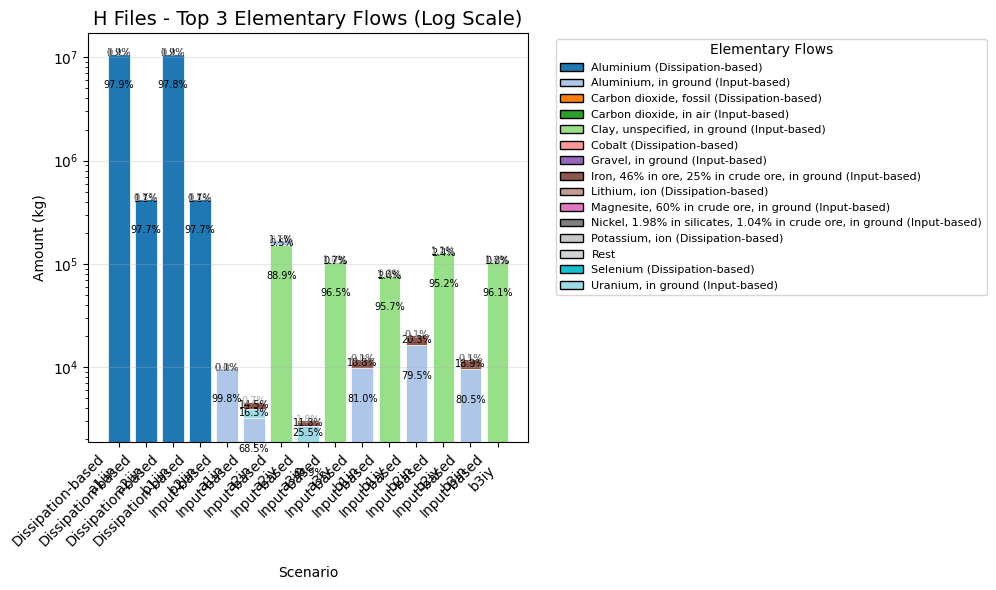

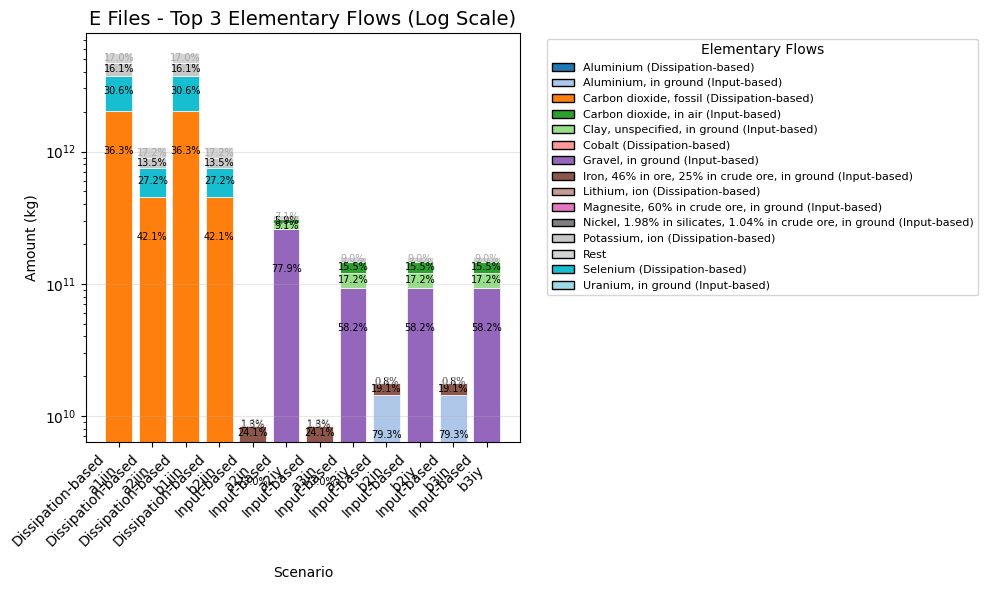

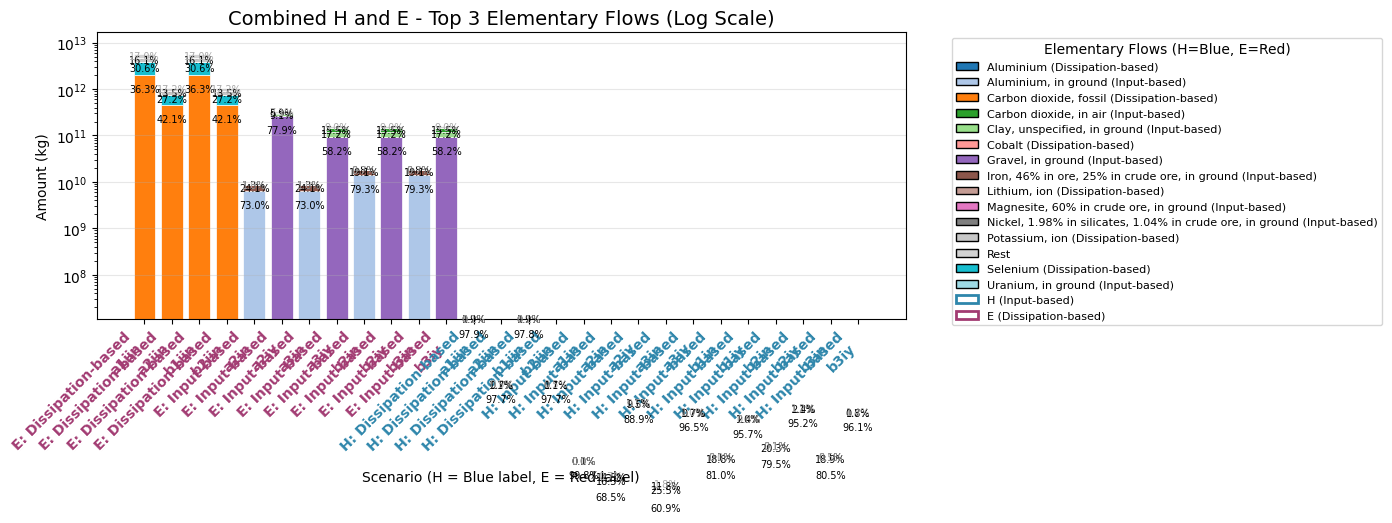

Top 3 contributors and Rest for each scenario:

E - Dissipation-based - a1iin: Total = 5587252100021.60 kg
  Carbon dioxide, fossil                  :  36.3%
  Selenium                                :  30.6%
  Potassium, ion                          :  16.1%
  Rest                                    :  17.0%

E - Dissipation-based - a2iin: Total = 1074092678173.98 kg
  Carbon dioxide, fossil                  :  42.1%
  Selenium                                :  27.2%
  Potassium, ion                          :  13.5%
  Rest                                    :  17.2%

E - Dissipation-based - b1iin: Total = 5587252100021.60 kg
  Carbon dioxide, fossil                  :  36.3%
  Selenium                                :  30.6%
  Potassium, ion                          :  16.1%
  Rest                                    :  17.0%

E - Dissipation-based - b2iin: Total = 1074092678173.98 kg
  Carbon dioxide, fossil                  :  42.1%
  Selenium                                :  27.2%

In [393]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from matplotlib.patches import Patch

# Define paths
results_dir = "results"  # Directory containing the CSV files

# CHANGED: New pattern to match both H and E files
file_pattern = r"CERC_(H|E)_.*\.csv"

# Find and categorize files
files = []
for f in os.listdir(results_dir):
    match = re.match(file_pattern, f)
    if match:
        file_type = match.group(1)  # H or E
        # Extract category from filename (Input-based or Dissipation-based)
        if "Input-based" in f:
            category = "Input-based"
        elif "Dissipation-based" in f:
            category = "Dissipation-based"
        else:
            category = "Unknown"
        
        # Extract identifier (parameter code)
        # Look for pattern like _b1iin.csv at the end
        id_match = re.search(r'_([a-z0-9]+)\.csv$', f)
        if id_match:
            identifier = id_match.group(1)
        else:
            identifier = "unknown"
            
        files.append((file_type, category, identifier, f))

# Sort by type, then category, then identifier
files.sort(key=lambda x: (x[0], x[1], x[2]))

# First pass: collect all flows that appear in top 3 of any scenario
all_top_flows = set(['Rest'])
file_data = []
flow_perspectives = {}  # Track which perspectives each flow appears in

for file_type, category, identifier, filename in files:
    filepath = os.path.join(results_dir, filename)
    df = pd.read_csv(filepath)
    total = df['amount'].sum()
    flow_amounts = df.groupby('flow')['amount'].sum()
    top3 = flow_amounts.nlargest(3)
    all_top_flows.update(top3.index)
    
    # Track perspectives for each flow
    for flow in top3.index:
        if flow not in flow_perspectives:
            flow_perspectives[flow] = set()
        flow_perspectives[flow].add(category)
    
    file_data.append((file_type, category, identifier, filepath, df, total, flow_amounts, top3))

# Assign consistent colors
flow_to_color = {}
colors = plt.cm.tab20(np.linspace(0, 1, len(all_top_flows))) # type: ignore
for i, flow in enumerate(sorted(all_top_flows)):
    if flow != 'Rest':
        flow_to_color[flow] = colors[i % len(colors)]
flow_to_color['Rest'] = 'lightgray'

# ============================================
# PLOT 1: H files only
# ============================================
h_files = [(ft, cat, id, fp, df, tot, fa, t3) for ft, cat, id, fp, df, tot, fa, t3 in file_data if ft == 'H']

if h_files:
    categories = []
    stack_data = []
    
    for file_type, category, identifier, filepath, df, total, flow_amounts, top3 in h_files:
        categories.append(f"{category}\n{identifier}")
        
        segments = []
        for flow, amount in top3.items():
            pct = (amount / total) * 100
            segments.append({
                'flow': flow,
                'amount': amount,
                'color': flow_to_color[flow],
                'percentage': pct
            })
        
        rest_amount = total - top3.sum()
        rest_pct = (rest_amount / total) * 100
        segments.append({
            'flow': 'Rest',
            'amount': rest_amount,
            'color': flow_to_color['Rest'],
            'percentage': rest_pct
        })
        stack_data.append(segments)
    
    # Plot H files
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(categories))
    bar_width = 0.8
    bottom = np.zeros(len(categories))
    
    for i, segments in enumerate(stack_data):
        current_bottom = bottom[i]
        for seg in segments:
            if seg['amount'] > 0:
                ax.bar(x[i], seg['amount'], width=bar_width,
                       bottom=current_bottom, color=seg['color'], edgecolor='white', linewidth=0.5)
                current_bottom += seg['amount']
                y_pos = current_bottom - seg['amount']/2
                text_color = 'black' if seg['flow'] != 'Rest' else 'darkgray'
                ax.text(x[i], y_pos, f"{seg['percentage']:.1f}%",
                       ha='center', va='center', fontsize=7, color=text_color)
        bottom[i] = current_bottom
    
    ax.set_yscale('log')
    ax.set_title('H Files - Top 3 Elementary Flows (Log Scale)', fontsize=14)
    ax.set_ylabel('Amount (kg)')
    ax.set_xlabel('Scenario')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    legend_elements = []
    for flow in sorted(all_top_flows):
        if flow != 'Rest':
            perspectives = ', '.join(sorted(flow_perspectives.get(flow, set())))
            label = f"{flow} ({perspectives})"
        else:
            label = flow
        legend_elements.append(Patch(facecolor=flow_to_color[flow], label=label, edgecolor='black'))
    ax.legend(handles=legend_elements, title='Elementary Flows', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

# ============================================
# PLOT 2: E files only
# ============================================
e_files = [(ft, cat, id, fp, df, tot, fa, t3) for ft, cat, id, fp, df, tot, fa, t3 in file_data if ft == 'E']

if e_files:
    categories = []
    stack_data = []
    
    for file_type, category, identifier, filepath, df, total, flow_amounts, top3 in e_files:
        categories.append(f"{category}\n{identifier}")
        
        segments = []
        for flow, amount in top3.items():
            pct = (amount / total) * 100
            segments.append({
                'flow': flow,
                'amount': amount,
                'color': flow_to_color[flow],
                'percentage': pct
            })
        
        rest_amount = total - top3.sum()
        rest_pct = (rest_amount / total) * 100
        segments.append({
            'flow': 'Rest',
            'amount': rest_amount,
            'color': flow_to_color['Rest'],
            'percentage': rest_pct
        })
        stack_data.append(segments)
    
    # Plot E files
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(categories))
    bar_width = 0.8
    bottom = np.zeros(len(categories))
    
    for i, segments in enumerate(stack_data):
        current_bottom = bottom[i]
        for seg in segments:
            if seg['amount'] > 0:
                ax.bar(x[i], seg['amount'], width=bar_width,
                       bottom=current_bottom, color=seg['color'], edgecolor='white', linewidth=0.5)
                current_bottom += seg['amount']
                y_pos = current_bottom - seg['amount']/2
                text_color = 'black' if seg['flow'] != 'Rest' else 'darkgray'
                ax.text(x[i], y_pos, f"{seg['percentage']:.1f}%",
                       ha='center', va='center', fontsize=7, color=text_color)
        bottom[i] = current_bottom
    
    ax.set_yscale('log')
    ax.set_title('E Files - Top 3 Elementary Flows (Log Scale)', fontsize=14)
    ax.set_ylabel('Amount (kg)')
    ax.set_xlabel('Scenario')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    legend_elements = []
    for flow in sorted(all_top_flows):
        if flow != 'Rest':
            perspectives = ', '.join(sorted(flow_perspectives.get(flow, set())))
            label = f"{flow} ({perspectives})"
        else:
            label = flow
        legend_elements.append(Patch(facecolor=flow_to_color[flow], label=label, edgecolor='black'))
    ax.legend(handles=legend_elements, title='Elementary Flows', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

# ============================================
# PLOT 3: Combined H and E with clear distinction
# ============================================
categories = []
stack_data = []
type_colors = {'H': '#2E86AB', 'E': '#A23B72'}  # Different colors for H and E bars

for file_type, category, identifier, filepath, df, total, flow_amounts, top3 in file_data:
    # Add type indicator to label
    label = f"{file_type}: {category}\n{identifier}"
    categories.append(label)
    
    segments = []
    for flow, amount in top3.items():
        pct = (amount / total) * 100
        segments.append({
            'flow': flow,
            'amount': amount,
            'color': flow_to_color[flow],
            'percentage': pct
        })
    
    rest_amount = total - top3.sum()
    rest_pct = (rest_amount / total) * 100
    segments.append({
        'flow': 'Rest',
        'amount': rest_amount,
        'color': flow_to_color['Rest'],
        'percentage': rest_pct
    })
    stack_data.append(segments)

# Plot combined
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(categories))
bar_width = 0.8
bottom = np.zeros(len(categories))

for i, segments in enumerate(stack_data):
    current_bottom = bottom[i]
    for seg in segments:
        if seg['amount'] > 0:
            ax.bar(x[i], seg['amount'], width=bar_width,
                   bottom=current_bottom, color=seg['color'], edgecolor='white', linewidth=0.5)
            current_bottom += seg['amount']
            y_pos = current_bottom - seg['amount']/2
            text_color = 'black' if seg['flow'] != 'Rest' else 'darkgray'
            ax.text(x[i], y_pos, f"{seg['percentage']:.1f}%",
                   ha='center', va='center', fontsize=7, color=text_color)
    bottom[i] = current_bottom

ax.set_yscale('log')
ax.set_title('Combined H and E - Top 3 Elementary Flows (Log Scale)', fontsize=14)
ax.set_ylabel('Amount (kg)')
ax.set_xlabel('Scenario (H = Blue label, E = Red label)')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Color code the x-tick labels
for tick_label, (file_type, _, _, _, _, _, _, _) in zip(ax.get_xticklabels(), file_data):
    if file_type == 'H':
        tick_label.set_color('#2E86AB')
        tick_label.set_weight('bold') # type: ignore
    else:
        tick_label.set_color('#A23B72')
        tick_label.set_weight('bold') # type: ignore

# Create legend with H/E distinction
legend_elements = []
for flow in sorted(all_top_flows):
    if flow != 'Rest':
        perspectives = ', '.join(sorted(flow_perspectives.get(flow, set())))
        label = f"{flow} ({perspectives})"
    else:
        label = flow
    legend_elements.append(Patch(facecolor=flow_to_color[flow], label=label, edgecolor='black'))

# Add H and E markers to legend
legend_elements.append(Patch(facecolor='none', edgecolor='#2E86AB', label='H (Input-based)', linewidth=2))
legend_elements.append(Patch(facecolor='none', edgecolor='#A23B72', label='E (Dissipation-based)', linewidth=2))

ax.legend(handles=legend_elements, title='Elementary Flows (H=Blue, E=Red)', 
         bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ============================================
# Original code - Print detailed breakdown
# ============================================
print("Top 3 contributors and Rest for each scenario:")
for file_type, category, identifier, filepath, df, total, flow_amounts, top3 in file_data:
    print(f"\n{file_type} - {category} - {identifier}: Total = {total:.2f} kg")
    for flow, amount in top3.items():
        pct = (amount / total) * 100
        print(f"  {flow:40s}: {pct:>5.1f}%")
    rest_pct = ((total - top3.sum()) / total) * 100
    print(f"  {'Rest':40s}: {rest_pct:>5.1f}%")

# 🔚 End